Optimization Workflow for Poloidal Field (PF) Coil Placement for Tokamaks
==========

# Loading libraries

## Useful libraries

In [1]:
import os
import sys
import json
import copy
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.optimize import minimize
from helper_functions_angle import resize_polygon, place_points, update_boundary, plot_coil
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

## Load TokaMaker library
To load the TokaMaker python module we need to tell python where to the module is located. This can be done either through the `PYTHONPATH` environment variable or using within a script using `sys.path.append()` as below, where we look for the environement variable `OFT_ROOTPATH` to provide the path to where the OpenFUSIONToolkit is installed (`/Applications/OFT` on macOS).

For meshing we will use the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain "gs_Domain" class to build a 2D triangular grid suitable for Grad-Shafranov equilibria. This class uses the [triangle code](https://www.cs.cmu.edu/~quake/triangle.html) through a simple internal python wrapper within OFT.

In [2]:
tokamaker_python_path = '/home/jerem/tokamaker/OpenFUSIONToolkit/libs/install_release'
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import gs_Domain, save_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_isoflux, read_eqdsk, eval_green
from OpenFUSIONToolkit.util import mu0

# 1. Equilibrium construction with TokaMaker

## Create mesh
First we define a target size to set the resolution in our grid. This variable will be used later and represent the target edge size within our mesh, where units are in meters. In this case we are using a fairly coarse resolution of 1.5 cm (10 radial points). Note that when setting up a new machine these values will need to scale with the overall size of the device/domain. It is generally a good idea perform a convergence study, by increasing resolution (decreasing target size) by at least a factor of two in all regions, when working with a new geometry to ensure the results are not sensitive to your choice of grid size.

### Define boundary

In [ ]:
# Loading machine LCFS & shot from EQDSK file
mesh_dx = 0.015
eqdsk = read_eqdsk('g192185.02440') # Machine shot
LCFS_contour = eqdsk['rzout'].copy()

### Define regions, attributes & geometry for region boundaries
We now create the mesh object and define the various logical mesh regions. In this case we only have one region, which is named `plasma` and is of type `plasma`. See other examples for more complex cases with other region types.

In [4]:
# Create a G-S domain
gs_mesh = gs_Domain()

# Define region information for mesh
gs_mesh.define_region('plasma',mesh_dx,'plasma')

# Define mesh geometry 
gs_mesh.add_polygon(LCFS_contour,'plasma')

### Generate mesh & plotting resulting regions and grid
Now we generate the actual mesh using the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain.build_mesh "build_mesh" method. This step may take a few moments as [triangle](https://www.cs.cmu.edu/~quake/triangle.html) generates the mesh.

Note that, as is common with unstructured meshes, the mesh is stored a list of points `mesh_pts` of size (np,2), a list of cells formed from three points each `mesh_lc` of size (nc,3), and an array providing a region id number for each cell `mesh_reg` of size (nc,), which is mapped to the names above using the `coil_dict` and `cond_dict` dictionaries.

In [5]:
mesh_pts, mesh_lc, mesh_reg = gs_mesh.build_mesh()

Assembling regions:
  # of unique points    = 294
  # of unique segments  = 2
Generating mesh:
  # of points  = 9280
  # of cells   = 18264
  # of regions = 1


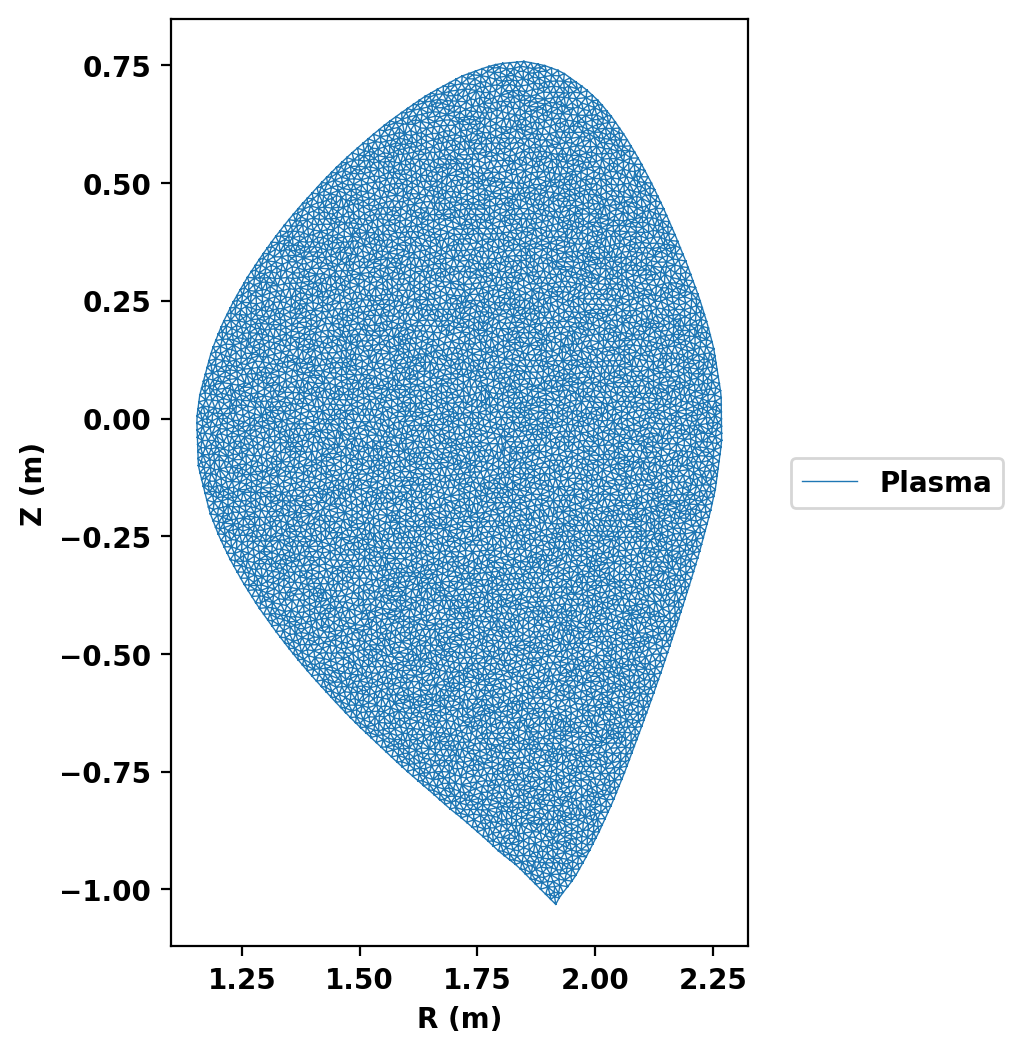

In [6]:
# Machine region and grid
fig, ax = plt.subplots(1,1,figsize=(5,8),constrained_layout=True)
gs_mesh.plot_mesh(fig,ax)

## Compute equilibria

### Initialize TokaMaker object
First we create a TokaMaker instance to use for equilibrium calculations. Note at present only a single instance can be used per python kernel, so this command should only be called **once** in a given Jupyter notebook or python script.

In [7]:
myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:   main
Revision id:          6165a5a
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Fortran input file    = /tmp/oft_10298/oftpyin
XML input file        = none
Integer Precisions    =    4   8
Float Precisions      =    4   8  10
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------



### Load mesh into TokaMaker
Now we load the mesh generated above using \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.setup_mesh "setup_mesh" and set the code to operate in fixed boundary mode by setting the `free_boundary` setting to False. Finally, we call \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.setup "setup" to setup the required solver objects. During this call we can specify the desired element order (min=2, max=4) and the toroidal field through F0 = B0*R0, where B0 is the toroidal field at a reference location R0.

In [8]:
mygs.setup_mesh(mesh_pts,mesh_lc)
mygs.settings.free_boundary = False

F0 = eqdsk['rcentr'] * eqdsk['bcentr']
mygs.setup(order=2,F0=F0)


**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.325E+00
    # of points  =    9280
    # of edges   =   27543
    # of cells   =   18264
    # of boundary points =     294
    # of boundary edges  =     294
    # of boundary cells  =     294
  Resolution statistics:
    hmin =  9.309E-03
    hrms =  1.365E-02
    hmax =  2.307E-02
  Surface grounded at vertex       7


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1



### Define global quantities and targets
For the Grad-Shafranov solve we define targets for the plasma current and the pressure.

In [9]:
Ip_target = eqdsk['ip']
pres_target = eqdsk['pres'][0]
mygs.set_targets(Ip=Ip_target, pax=pres_target)

### Initialize the flux function & compute a fixed-boundary equilibrium
Before running a calculation for the first time we must initialize the flux function $\psi$, which can be done using \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.init_psi "init_psi". By default this calculation uses a uniform current (equal to Ip_target) over the full plasma domain. Then we can compute an equilibrium in this geometry.

In [10]:
# flux function initialization
err_flag = mygs.init_psi()

# Computing the equilibrium
err_flag = mygs.solve()

Starting non-linear GS solver
     1  7.4958E-01  8.5761E-02  3.9810E-04  1.7868E+00 -4.0450E-02  0.0000E+00
     2  9.0890E-01  6.8636E-02  1.2693E-04  1.7821E+00 -4.0411E-02  0.0000E+00
     3  9.4714E-01  6.4809E-02  4.5446E-05  1.7796E+00 -4.0323E-02  0.0000E+00
     4  9.5804E-01  6.3765E-02  1.7289E-05  1.7784E+00 -4.0249E-02  0.0000E+00
     5  9.6136E-01  6.3458E-02  6.7274E-06  1.7780E+00 -4.0199E-02  0.0000E+00
     6  9.6241E-01  6.3363E-02  2.6307E-06  1.7778E+00 -4.0170E-02  0.0000E+00
     7  9.6275E-01  6.3333E-02  1.0278E-06  1.7777E+00 -4.0155E-02  0.0000E+00
     8  9.6286E-01  6.3323E-02  4.0084E-07  1.7776E+00 -4.0147E-02  0.0000E+00
 Timing:  0.30310775499992815     
   Source:    0.19650078899985601     
   Solve:      8.6812261999966722E-002
   Boundary:   3.4049609998874075E-003
   Other:      1.6389743000218004E-002


### Print information and plot equilibrium
After computing the equilibrium, basic parameters can be displayed using the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.print_info "print_info" method. For access to these quantities as variables instead the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.get_stats "get_stats" can be used.

Flux surfaces can be plotted using the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.plot_psi "plot_psi" method. Additional plotting methods are also available to display other information for more complex cases. See other examples and the documentation for more information.

Equilibrium Statistics:
  Topology                =   Limited
  Toroidal Current [A]    =    4.9332E+05
  Current Centroid [m]    =    1.737 -0.051
  Magnetic Axis [m]       =    1.778 -0.040
  Elongation              =    1.547 (U:  1.428, L:  1.665)
  Triangularity           =   -0.288 (U: -0.233, L: -0.344)
  Plasma Volume [m^3]     =   14.542
  q_0, q_95               =    2.842  5.677
  Peak Pressure [Pa]      =    6.8215E+03
  Stored Energy [J]       =    5.1004E+04
  <Beta_pol> [%]          =   28.3943
  <Beta_tor> [%]          =    0.1635
  <Beta_n>   [%]          =    0.3474
  Diamagnetic flux [Wb]   =    5.2050E-03
  Toroidal flux [Wb]      =    2.5316E+00
  l_i                     =    0.7618


/tmp/ipykernel_10298/277223278.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


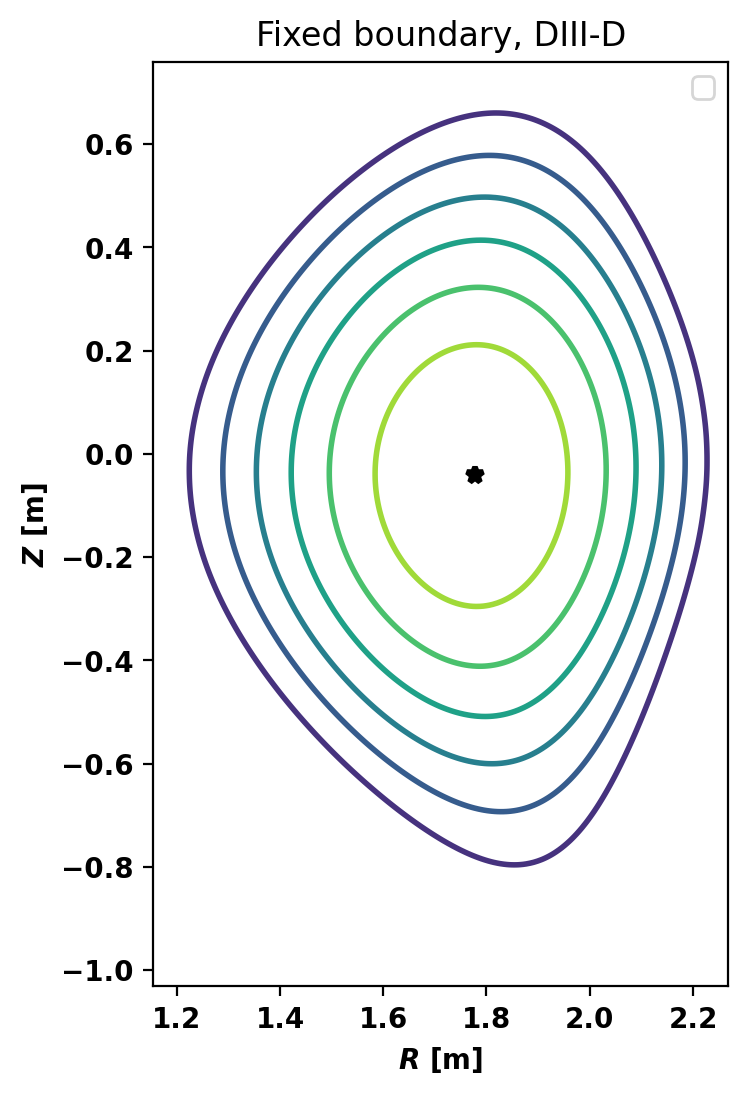

In [11]:
mygs.print_info()

# Plot flux surfaces
fig, ax = plt.subplots(1,1)
mygs.plot_psi(fig,ax)
plt.xlabel('$R$ [m]')
plt.ylabel('$Z$ [m]')
plt.title('Fixed boundary, DIII-D')
plt.legend()

In [12]:
# will be one of the targets for the free-boundary case
fixed_mag_axis = mygs.o_point.copy()

## Boundary flux

- $r\_bnd$ represents the (R, Z) coord. along the fixed boundary where vacuum flux is evaluated (shape (n, 2))
- $psi\_bnd$ represents the vacuum flux values at each of those boundary positions

Computing fixed boundary vacuum flux
 Computing flux BC matrix 
 Inverting real matrix
   Time =    1.6031304999999999E-002
 Starting LU solver: umfpack T


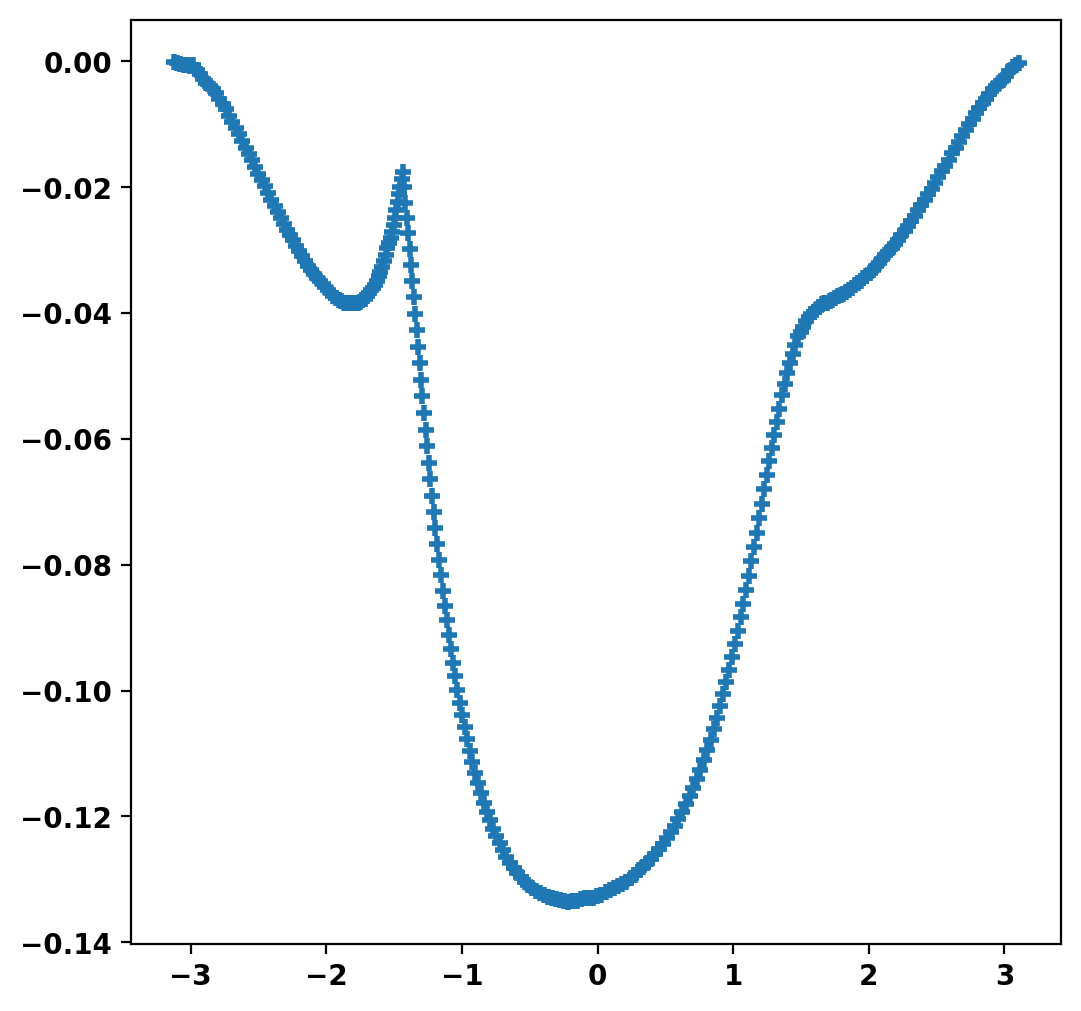

In [13]:
r_bnd, psi_bnd = mygs.get_vfixed()

# Plot required relative flux on boundary
fig, ax = plt.subplots()
theta = np.arctan2(r_bnd[:,1],r_bnd[:,0]-mygs.o_point[0])
_=ax.plot(theta[1:],psi_bnd[1:]-psi_bnd[0],'+')

# 2. Optimization process

## Grid resolution and geometry of the machine 

In [14]:
# grid resolution
plasma_dx = 0.04
coil_dx = 0.03
vv_dx = 0.04
vac_dx = 0.10

In [15]:
# Geometry
with open('DIIID_geom.json','r') as fid:
    DIIID_geom = json.load(fid)

# Get the limiter
lim0 = np.array(DIIID_geom['limiter'])

# generates a modified limiter with parameters (return a list of (R,Z) coord of plasma bound.)
lim = update_boundary(r0=1.69, z0=0, a0=0.67, kappa=2, delta=0.8, squar=0.15, npts=400) 
                                                                                       
# coil_centers_cand contains 'npts' candidate positions (dx: dist between limiter and coils)
coil_center_cand = resize_polygon(lim, dx=0.3)

## Core functions

In [16]:
def make_new_coils(
        nCoils, 
        pol_angles,
        dx=0.08, 
        dy=0.08,
        ifplot=True,
        distribution2=None 
):
    """
    Generates and places poloidal field (PF) coils given their poloidal angles. 
    It creates a set of coil pairs (one above and one below the midplane) whose
    size can be changed thanks to dx & dy. Optionally plots two coil configurations.

    Parameters:
        - nCoils: Number of coils (in the top-side)
        - pol_angles: List of poloidal angles (degrees)
        - dx: Horizontal coil size
        - dy: Vertical coil size
        - ifplot: Boolean, whether to plot the given coil distribution
        - distribution2: (Optional) second list of poloidal angles

    Returns:
        scan_geom (dictionary): Dict. containing the data of the coil distr.
    """
    
    scan_geom = {}
    scan_geom["coils"] = {}
    
    # Defining coil locations for the first distribution (2nd arg is just the top-side of coil_center_cand)
    inds, locs = place_points(nCoils, coil_center_cand[:len(coil_center_cand)//2,:], pol_angles)
    
    # Creating coil pairs for (1st) distribution
    for i, loc in enumerate(locs):
        pts_top = np.array([[loc[0]-dx, loc[1]+dy], [loc[0]+dx, loc[1]+dy], 
                            [loc[0]+dx, loc[1]-dy], [loc[0]-dx, loc[1]-dy]])
        pts_bot = pts_top * np.array([1, -1])

        # Storing coils
        scan_geom["coils"][f'F{i}A'] = {'pts': copy.deepcopy(pts_top), 'nturns': 1.0}
        scan_geom["coils"][f'F{i}B'] = {'pts': copy.deepcopy(pts_bot), 'nturns': 1.0}

    if ifplot:
        # Make the figure
        plt.figure(figsize=(6, 10))
        ax = plt.subplot(111)
        ax.axis('equal')

        # Plot the limiter
        plt.plot(np.hstack((lim0[:, 0], lim0[0, 0])), np.hstack((lim0[:, 1], lim0[0, 1])), c='k')
        plt.plot(lim[:, 0], lim[:, 1], c='k', ls=':')

        # Plot the first set of coils
        for coil in scan_geom["coils"]:
            if 'ECOIL' not in coil:
                pts = np.array(scan_geom["coils"][coil]['pts'])
                plot_coil(pts, ax) 
                plt.text(np.average(pts[:, 0]), np.average(pts[:, 1]), coil, ha='center', va='center')

        # If provided, plot the (2nd) distrib
        if distribution2 is not None:
            scan_geom_2 = {}
            scan_geom_2["coils"] = {}
            inds2, locs2 = place_points(nCoils, coil_center_cand[:len(coil_center_cand)//2, :], distribution2)

            for i, loc in enumerate(locs2):
                pts_top2 = np.array([[loc[0]-dx, loc[1]+dy], [loc[0]+dx, loc[1]+dy], 
                                     [loc[0]+dx, loc[1]-dy], [loc[0]-dx, loc[1]-dy]])
                pts_bot2 = pts_top2 * np.array([1, -1])

                # Storing second set of coils, oF -> just name for optimized distrib
                scan_geom_2["coils"][f'oF{i}A'] = {'pts': copy.deepcopy(pts_top2), 'nturns': 1.0}
                scan_geom_2["coils"][f'oF{i}B'] = {'pts': copy.deepcopy(pts_bot2), 'nturns': 1.0}

            # Plot the second set of coils in a different color (e.g., red)
            for coil in scan_geom_2["coils"]:
                if 'ECOIL' not in coil:
                    pts2 = np.array(scan_geom_2["coils"][coil]['pts'])
                    plot_coil(pts2, ax)  
                    ax.plot(pts2[:, 0], pts2[:, 1], 'r')
                    plt.text(np.average(pts2[:, 0]), np.average(pts2[:, 1]), coil, ha='center', va='center', color='r')

        ax.set_xlabel('$R$ [m]')
        ax.set_ylabel('$Z$ [m]')

    return scan_geom

In [17]:
def compute_coil_centers(scan_geom):
    """
    Compute the center of each coils (squares)

    Parameter: 
        - scan_geom: dict with coils informations
        
    return:   
        - coil_centers: coils centers of both top & bottom side (2D array, (R,Z) position)
    """
    coil_centers = []

    # Loading and computing the mean of coil edges for each coil
    for i, coil in enumerate(scan_geom["coils"]):
        pts = np.array(scan_geom["coils"][coil]["pts"])
        center = np.mean(pts, axis=0) # mean along column

        # Store the center as a pair (for a single coil)
        coil_centers.append(np.asarray([center]))  # Each element is a 2D array with one center

    return coil_centers

In [18]:
def sort_coils_curr(angle_distr, currents):
    """
    Sorts the given coil poloidal angles set and currents.

    Arguments:
        - angle_distr: List of poloidal angles (degrees) for coil positions
        - currents: Associated list of currents

    returns:
        - sort_angle_distr: sorted list of poloidal angles
        - sort_curr: sorted list of currents
    """
    if len(currents) != 2 * len(angle_distr):
        raise ValueError("Length of currents must be twice the length of coil angles distribution.")
    
    angle_distr = np.array(angle_distr)
    currents = np.array(currents)
    
    # gives sorted indices and sorts angle distr 
    sort_idx = np.argsort(angle_distr)
    sort_angle_distr = angle_distr[sort_idx]

    # Sorts currents accordingly 
    sort_curr = np.empty_like(currents)

    for new_i, old_i in enumerate(sort_idx):
        sort_curr[2*new_i] = currents[2*old_i]
        sort_curr[2*new_i + 1] = currents[2*old_i + 1]
    
    return sort_angle_distr, sort_curr

In [40]:
def opt_coil_loc(init_angles, bounds, scan=False, plot_err=False, plot_info=True):
    """
    Performs an outer-loop optimization over the poloidal coil positions. 
    For each configuration, it solves an inner loop (Least-Squares problem) in order to get 
    the optimal coil currents that minimize the flux error on the boundary. Then, the final error 
    from this inner problem is used as the cost function for optimizing coil locations.

    Arguments:
        - init_angles: Initial list of poloidal angles (degrees) in top-side
        - bounds: specify the bounds in which each poloidal angle can vary (list) 
        - scan: if True, return also the final cost (useful if we perform a parameter scan on opt_coil_loc and 
                                                and are interested for the lowest value)
        - plot_err: if True, plot the error w.r.t to the current optimization (inner loop)
        - plot_info: if True, plot informations related to the optimization

    Returns:
        - Optimized coil positions as an array of poloidal angles (degrees)
    """
    # Number of coils in the upper part (with symmetry, the total number of coils is 2 * num_coils)
    num_coils = len(init_angles)

    # Storing final results
    final_currs = None 
    final_con = None    
    final_inner_cost = None 

    def objective(init_angles):
        """
        Objective function for optimizing coil locations. It first determines the best coil currents for a 
        given coil config, then returns the corresponding cost solving a Least-squares problem.
        
        Arguments:
            - poloidal_angles: List of poloidal angles
        
        Returns:
            -  final_cost[0]: Cost function value based on optimal currents for the given positions
        """
        # To be accessible outside this function
        nonlocal final_currs, final_con, final_inner_cost 

        # Loading new coil configuration (name, positions, etc)
        scan_geom_DIIID = make_new_coils(num_coils, init_angles, ifplot=False)

        # compute coil centers
        new_coil_center = compute_coil_centers(scan_geom_DIIID)

        ### Least squares method ########     
        con = np.zeros((psi_bnd.shape[0]+len(new_coil_center)-1, len(new_coil_center)))
        
        for i, coil_set in enumerate(new_coil_center):
            flux_tmp = np.zeros((psi_bnd.shape[0],))
            for coil in coil_set:
                flux_tmp += eval_green(r_bnd,coil)
            con[:psi_bnd.shape[0]-1,i] = flux_tmp[1:] - flux_tmp[0]
            con[psi_bnd.shape[0]-1+i,i] = 1.E-9 # Regularization term

        # Performs least-squares fit
        err = np.zeros((psi_bnd.shape[0]+len(new_coil_center)-1,))
        err[:psi_bnd.shape[0]-1] = psi_bnd[1:] - psi_bnd[0]
        currs, final_cost, _, _ = np.linalg.lstsq(con, err, rcond=None)
        #print("final cost inner loop: ", final_cost[0])

        final_currs = currs  # Store the final currents
        final_con = con      # Store the final con matrix

        final_inner_cost = final_cost[0].copy()
        #################################

        return final_cost[0]
    
    # (outer loop) Coil position optimization
    result = minimize(objective, init_angles, method='Powell', bounds=bounds, tol = 1e-12, options={'disp': True})

    if plot_err == True:
        # Ensure final_con is not None before plotting
        if final_con is not None and final_currs is not None:
            fig, ax = plt.subplots()
            ax.plot(theta[1:], psi_bnd[1:] - psi_bnd[0], 'o', label="Boundary flux")
            ax.plot(theta[1:], np.dot(final_con, final_currs)[:psi_bnd.shape[0] - 1], '+', label="Computed Flux")
            ax.set_xlabel("$\Theta$", fontsize=12)
            ax.set_ylabel("boundary flux")
            ax.legend()
            plt.show()
    
    if plot_info is True:
        # Print outer loop informations
        print("outer cost: ", result.fun)
        print("inner cost: ", final_inner_cost)
        print("number of iterations for the outer loop: ", result.nit)
        print("success: ", result.success)
        print("status: ", result.status)
        print("message: ", result.message)

    if scan is True:
        return result.x, result.fun, final_currs, final_inner_cost
    else:
        # Optimized distribution
        return result.x, final_currs

<>:80: SyntaxWarning: invalid escape sequence '\T'
<>:80: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_10298/3261423104.py:80: SyntaxWarning: invalid escape sequence '\T'
  ax.set_xlabel("$\Theta$", fontsize=12)


In [57]:
def opt_coil_loc_curr(init_angles, bounds, lambda_curr, reg_in=1e-9, scan=False, plot_err=False, plot_info=True):
    """
    Performs an outer-loop optimization over the poloidal coil positions with regularization terms. 
    For each configuration, it solves an inner loop (Least-Squares problem) in order to get 
    the optimal coil currents that minimize the flux error on the boundary. Then, the final error 
    from this inner problem is used as the cost function for optimizing coil locations. 

    Arguments:
        - init_angles: Initial list of poloidal angles (degrees) in top-side
        - bounds: specify the bounds in which each poloidal angle can vary (list) 
        - lambda_curr: Regularization for the currents
        - reg_in: Regularization term in inner loop
        - scan: if True, return also the final cost (useful if we perform a parameter scan on opt_coil_loc and 
                                                and are interested for the lowest value)
        - plot_err: if True, plot the error w.r.t to the current optimization (inner loop)

    Returns:
        - Optimized coil positions as an array of poloidal angles (degrees)
    """
    # Number of coils in the upper part (with symmetry, the total number of coils is 2 * num_coils)
    num_coils = len(init_angles)

    # Storing final results
    final_currs = None 
    final_con = None    
    inner_cost = None
    final_inner_cost = None 

    def objective(init_angles):
        """
        Objective function for optimizing coil locations. It first determines the best coil currents for a 
        given coil config, then returns the corresponding cost solving a Least-squares problem.
        
        Arguments:
            - poloidal_angles: List of poloidal angles
        
        Returns:
            -  final_cost[0]: Cost function value based on optimal currents for the given positions
        """
        # To be accessible outside this function
        nonlocal final_currs, final_con, inner_cost, final_inner_cost 

        # Loading new coil configuration (name, positions, etc)
        scan_geom_DIIID = make_new_coils(num_coils, init_angles, ifplot=False)

        # compute coil centers
        new_coil_center = compute_coil_centers(scan_geom_DIIID)

        ### Least squares method ########     
        con = np.zeros((psi_bnd.shape[0]+len(new_coil_center)-1, len(new_coil_center)))
        
        for i, coil_set in enumerate(new_coil_center):
            flux_tmp = np.zeros((psi_bnd.shape[0],))
            for coil in coil_set:
                flux_tmp += eval_green(r_bnd,coil)
            con[:psi_bnd.shape[0]-1,i] = flux_tmp[1:] - flux_tmp[0]
            con[psi_bnd.shape[0]-1+i,i] = reg_in # Regularization term

        # Performs least-squares fit
        err = np.zeros((psi_bnd.shape[0]+len(new_coil_center)-1,))
        err[:psi_bnd.shape[0]-1] = psi_bnd[1:] - psi_bnd[0]
        currs, final_cost, _, _ = np.linalg.lstsq(con, err, rcond=None)
        #print("final cost inner loop: ", final_cost[0])
        #################################

        final_currs = currs  # Store the final currents
        final_con = con      # Store the final con matrix
        
        # Inner cost (without reg term on currents)
        inner_cost = final_cost[0].copy()

        # L2 regularization of currents
        reg_term = lambda_curr * np.sum(currs**2)

        return inner_cost + reg_term
    
    # (outer loop) Coil position optimization
    result = minimize(objective, init_angles, method='Powell', bounds=bounds, tol = 1e-12, options={'disp': True})

    if plot_err == True:
        # Ensure final_con is not None before plotting
        if final_con is not None and final_currs is not None:
            fig, ax = plt.subplots()
            ax.plot(theta[1:], psi_bnd[1:] - psi_bnd[0], 'o', label="Boundary flux")
            ax.plot(theta[1:], np.dot(final_con, final_currs)[:psi_bnd.shape[0] - 1], '+', label="Computed Flux")
            # Add reg_in and reg_out to legend as a dummy line
            ax.plot([], [], ' ', label=fr"$\lambda_{{\mathrm{{in}}}} = {reg_in:.1e}$")
            ax.plot([], [], ' ', label=fr"$\lambda_{{\mathrm{{out}}}} = {lambda_curr:.1e}$")
            ax.set_xlabel("$\Theta$", fontsize=12)
            ax.set_ylabel("boundary flux")
            ax.legend()
            plt.show()
    
    if plot_info is True:
        # Print outer loop informations
        print("current lambda_curr: ", lambda_curr)
        print("outer cost: ", result.fun)
        print("inner cost: ", inner_cost)
        print("final inner cost (with reg. term for currents): ", final_inner_cost)
        print("number of iterations for the outer loop: ", result.nit)
        print("success: ", result.success)
        print("status: ", result.status)
        print("message: ", result.message)

    if scan is True:
        return result.x, result.fun, final_currs, inner_cost
    else:
        # Optimized distribution
        return result.x, final_currs

<>:89: SyntaxWarning: invalid escape sequence '\T'
<>:89: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_10298/505859440.py:89: SyntaxWarning: invalid escape sequence '\T'
  ax.set_xlabel("$\Theta$", fontsize=12)


## 3. Example

Here, a simple optimization example is given:

- $initial\_pol$: contains the first guess
- $bound\_ex$: gives the bounds in which the angles are free to move (during the optimization process)
- $opt\_pol$ & $final\_currs\_pol$: are the resulting optimized set of poloidal angles (top-side) & currents (top & bottom-side).

### Optimization process

Compute optimized poloidal angles & currents for a manual case

Optimization terminated successfully.
         Current function value: 0.000016
         Iterations: 7
         Function evaluations: 1644


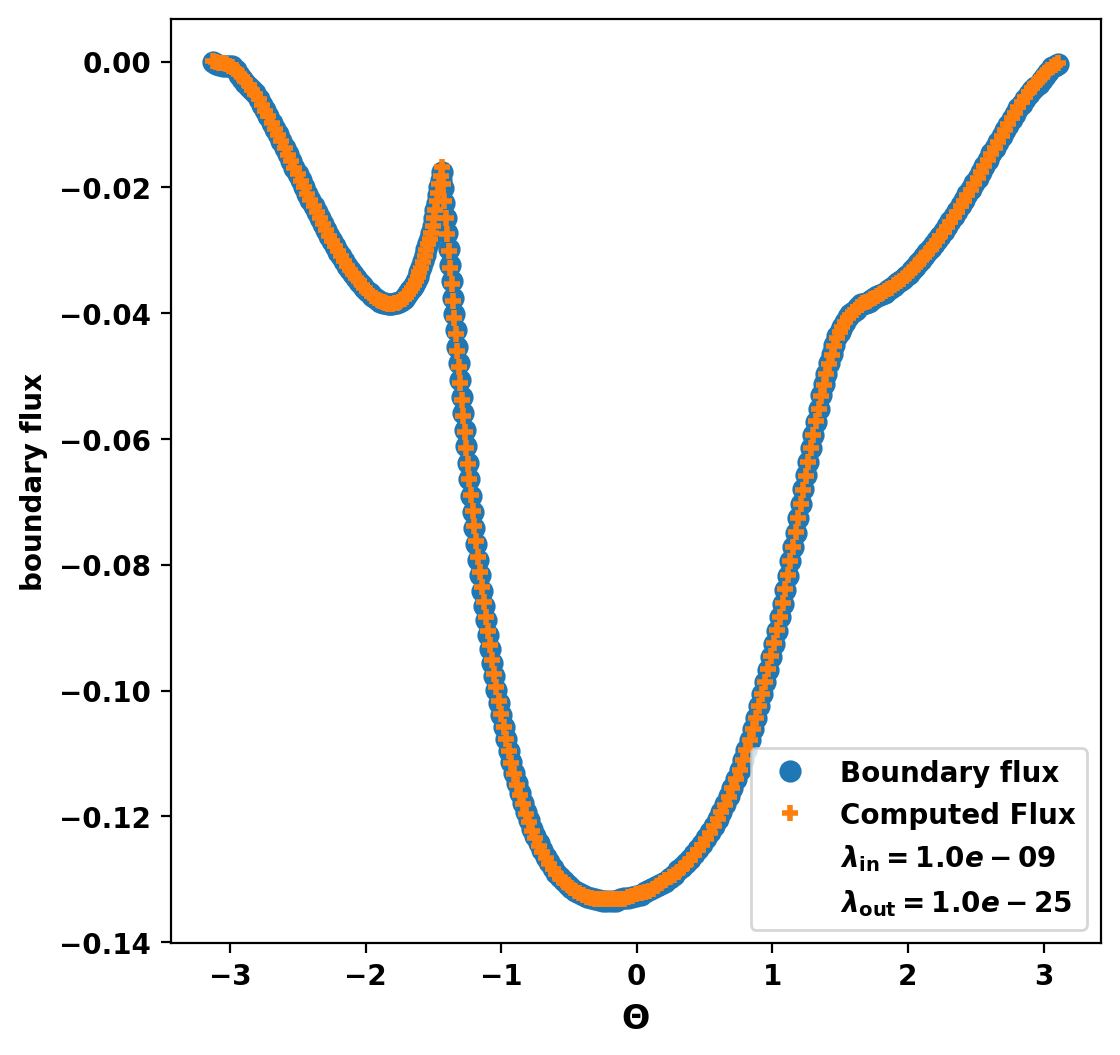

current lambda_curr:  1e-25
outer cost:  1.575186924033465e-05
inner cost:  1.5751869085003286e-05
final inner cost (with reg. term for currents):  None
number of iterations for the outer loop:  7
success:  True
status:  0
message:  Optimization terminated successfully.

Optimized poloidal angles:  [  0.83267474  15.03170463  63.09382311  89.26579495 149.89227631]

Optimized currents:  [ 403319.00978707  324794.96821579   18168.01901128  -10362.96233944
  122162.62342477  148582.03699627 -324436.70031471 -424876.80922313
  572636.47290951  796257.40695685]


In [55]:
initial_pol = [20, 55, 90, 115, 160]
bound_ex = [(0, 180)] * (len(initial_pol))

# Regularization terms for inner loop (reg_in) and outer (reg_out)
reg_in = 1e-9
reg_out = 1e-25

# opt_pol, final_outer_cost_pol, final_currs_pol, final_inner_cost_pol = opt_coil_loc(initial_pol, bound_ex, scan=True, plot_err=True)
opt_pol_reg, outer_cost_reg, currs_reg, inner_cost_reg = opt_coil_loc_curr(initial_pol, bound_ex, reg_out, reg_in, scan=True, plot_err=True)

sort_opt_pol_reg, sort_currs_reg = sort_coils_curr(opt_pol_reg, currs_reg)

print("")
print("Optimized poloidal angles: ", sort_opt_pol_reg)
print("")
print("Optimized currents: ", sort_currs_reg)

### Outputs visualization 

Here, we can visualize the initial coil distribution (in black) & the optimized one (in red)

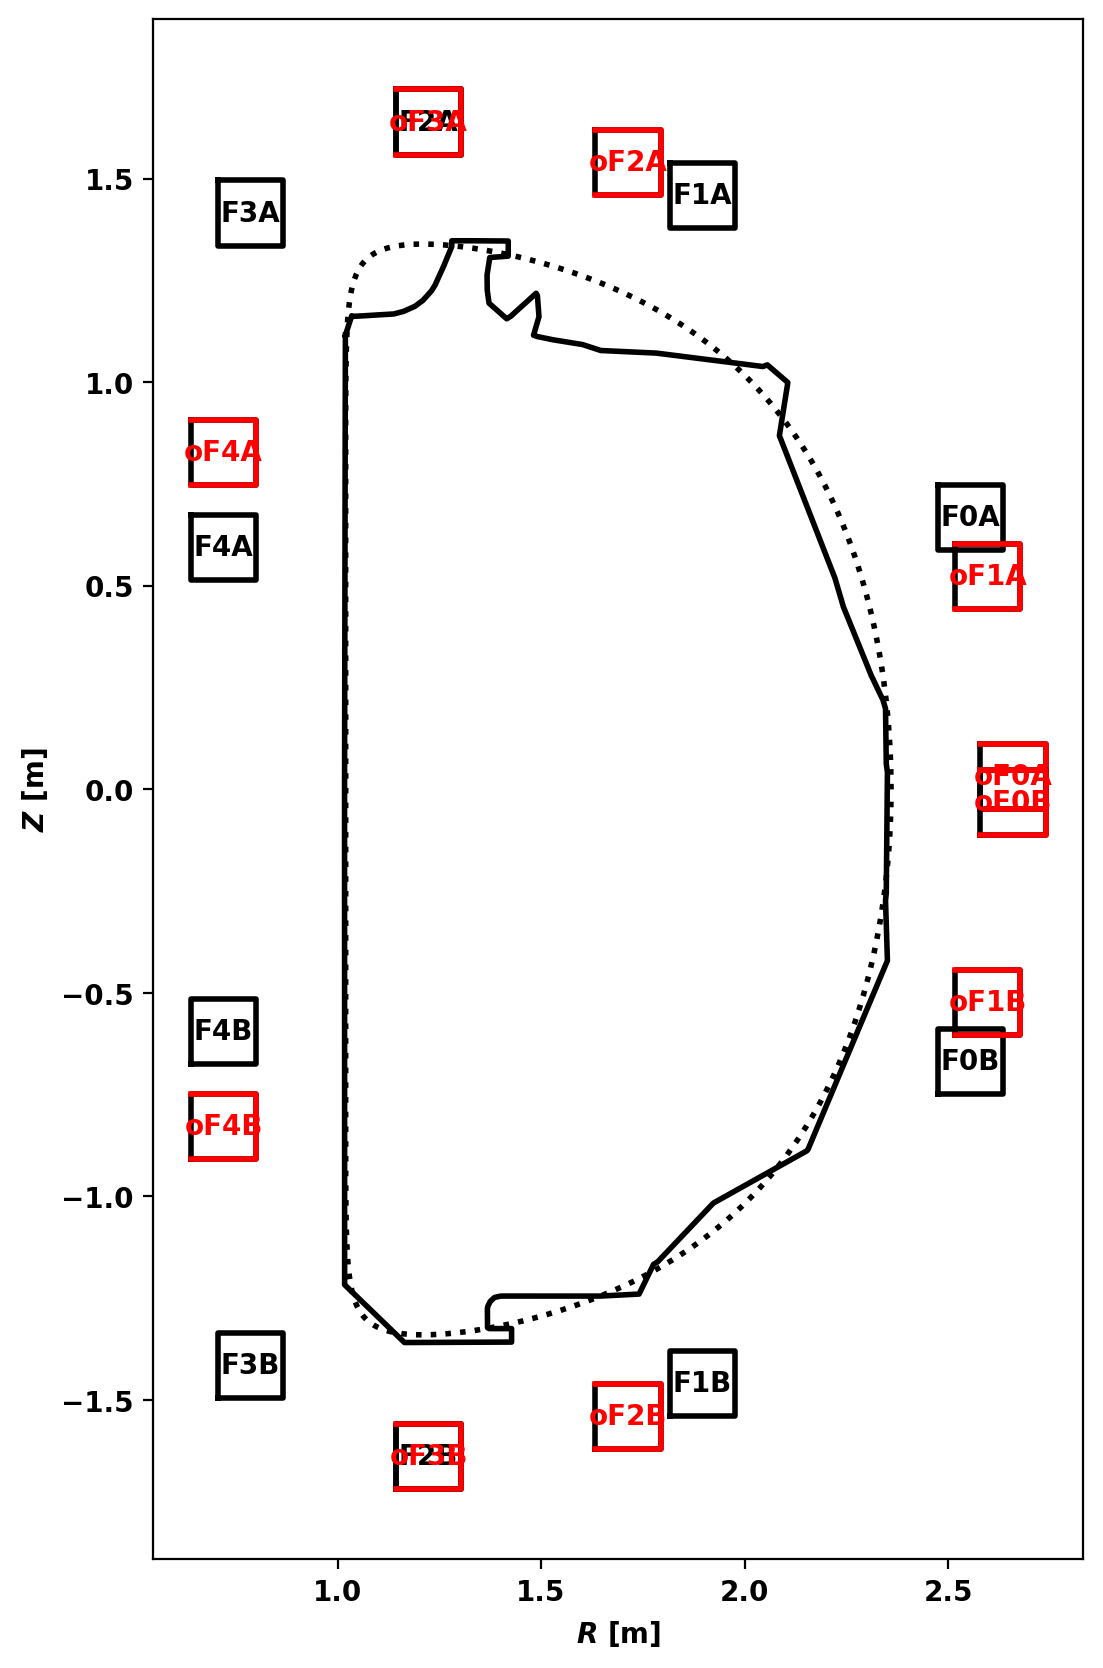

In [34]:
scan_geom_test = make_new_coils(len(initial_pol), initial_pol, distribution2=sort_opt_pol_reg)

# 4. Method for identifying the optimized coil distribution with lowest total current

## Method steps

The following method is designed to identify the optimized distribution of poloidal coil locations with the lowest total current, for a given set of parameters. The procedure can be run by the function `opt_coil_loc_full()` and involves several iterative steps:

1. **Initialization**  
   Define the following parameters:  
   - (i) `ncoil`: the number of coils on the top side of the machine  
   - (ii) `t`: the threshold value for the outer cost
   - (iii) `nb_distr`: the number of initial coil distributions`
   - (iv) `dtheta1`: angle difference from fixed angle and lower bound of the range for next coils
   - (v) `dtheta2`: angle deviation from fixed angle to define initial ranges during the last step

2. **Initial distribution generation**  
   Generate `nb_distr` random coil distributions, where each coil angle is sampled uniformly in the range (0, 180).

3. **Optimization and filtering**  
   Apply the optimization process to each distribution. Only the optimized configurations with an outer cost lower than the defined threshold `t` are retained for further analysis.

4. **Angle density analysis**  
   For each coil index, plot the density with the function `plot_densities()` of the poloidal angles across the retained configurations. This quantifies how frequently specific angles appear for each coil index.

5. **Fixing the first coil**  
   Identify the most represented angle (density peak) for the first coil, $pol1$. Repeat steps 2–4, but this time, fix the first poloidal angle to $pol1$ in all new initial distributions, and let the other angles vary in a range ($pol1$ + `dtheta1`).
6. **Iterative fixing of additional coils**  
   Continue the process by identifying the peak for the second coil, then repeating steps 2–4 with both the first and second angles fixed.  
   This step-by-step fixing continues until all coil angles are determined. During the optimization process, each fixed angle $pol$ can vary in ($pol$ - `dtheta2`, $pol$ + `dtheta2`).

7. **Final step**  
   In the final step, generate `nb_distr` distributions where each coil angle is sampled from a narrow interval centered around the considered fixed angle $pol$, i.e ($pol$ - `dtheta2`, $pol$ + `dtheta2`). Then, each of these are optimized where the same bounds are used and a list of optimized poloidal angles distributions `opt_pol_list` and a list of their associated currents distributions `opt_curr_list` are returned.

NOTE: 
- The coil indexes follow the trigonometric direction, i.e the smallest angle will be coil #1, and so on.
- `dtheta1` avoids having overlaps between two coil indexes.

In [77]:
def plot_densities(
        nCoils, 
        pol_angles_list, 
        dx=0.08, 
        dy=0.08,
        ifplot=True
):
    """
    Plots (1) coil center distributions in R-Z and (2) density curves showing
    poloidal angle frequency per coil index.

    Parameters:
        - nCoils: Number of coils
        - pol_angles_list: List of poloidal angle distributions (list of lists)
        - dx: Horizontal coil size
        - dy: Vertical coil size
        - ifplot: Boolean, whether to plot

    Returns:
        None
    """
    from scipy.stats import gaussian_kde

    # Sort each distribution
    pol_angle_list_sorted = [sorted(pol_list) for pol_list in pol_angles_list]

    # Prepare color map (tab10 supports up to 10 distinct colors, one per coil #
    cmap = plt.get_cmap('tab10')
    coil_colors = [cmap(i % 10) for i in range(nCoils)]
    
    # Store coil center positions (R,Z) and poloidal angles
    RZ_by_index = [[] for _ in range(nCoils)]
    angles_by_index = [[] for _ in range(nCoils)]
    
    # loop over all distributions
    for pol_angles in pol_angle_list_sorted:
        # Loading center coords for a given distrib
        _, locs = place_points(nCoils, coil_center_cand[:len(coil_center_cand)//2, :], pol_angles)
        locs = np.array(locs)
        
        # loop over the number of coils
        for i in range(nCoils):
            # Adding center coord & poloidal angle of coil #i to the given distrib
            RZ_by_index[i].append(locs[i])
            angles_by_index[i].append(pol_angles[i])  # store angle for this coil in this distribution


    #### Plot 1: Coil centers in R-Z ###
    if ifplot:
        plt.figure(figsize=(6, 10))
        ax = plt.subplot(111)
        ax.axis('equal')

        ax.plot(np.hstack((lim0[:, 0], lim0[0, 0])), np.hstack((lim0[:, 1], lim0[0, 1])), c='k')
        ax.plot(lim[:, 0], lim[:, 1], c='k', ls=':')

        for i in range(nCoils):
            RZ = np.array(RZ_by_index[i])
            #print(RZ)
            #print("")
            if len(RZ) > 0:
                ax.scatter(RZ[:, 0], RZ[:, 1], color=coil_colors[i], alpha=0.2, s=45) # RZ[:, 0] is the R coord of coil #i (for all distrib)
                                                                                      # RZ[:, 1] is the Z coord of coil #i (for all distrib)

        ax.set_xlabel('R (m)')
        ax.set_ylabel('Z (m)')
        ax.set_title("Coil Center Distribution")

    
    ### Plot 2: Poloidal angle histogram curves ###
    if ifplot:
        plt.figure(figsize=(7, 5))

    x_vals = np.linspace(0, 180, 500) 

    # Will store the densities for each coil # 
    all_densities = []
    all_angles = []

    for i in range(nCoils):
        angle_vals = np.array(angles_by_index[i])
        if len(angle_vals) >= 1:
            # creating densities
            kde = gaussian_kde(angle_vals, bw_method=0.05)
            density = kde(x_vals)
            density /= np.max(density)  # Normalization

            # storing density function for coil #i
            all_densities.append(density)
            all_angles.append(x_vals)

            if ifplot:
                plt.plot(x_vals, density, label=f'Coil {i+1}', color=coil_colors[i], lw=2)

    if ifplot:
        plt.xlabel(r"$\theta$ (degrees)", fontsize=12)
        plt.ylabel("density")
        plt.title("Angle Frequency per Coil Index")
        plt.legend()
        plt.tight_layout()

    return RZ_by_index, angles_by_index, all_densities


In [80]:
def opt_coil_loc_full(
    ncoil,
    t,
    nb_distr,
    regin,
    regout,
    dtheta1,
    dtheta2,
    plot_steps=True
):
    """
    Performs a multi-step optimization of poloidal field (PF) coil locations. Iteratively constructs 
    and refines coil angle distributions by fixing poloidal angles based on density peaks from previous 
    runs. At each stage, it updates the bounds accordingly. The final step performs an optimization around the selected angles.  
    Optionally plots intermediate results.
    
    Parameters:
        - ncoil: Number of coils (in the top-side)
        - t: Threshold for optimization process
        - nb_distr: Number of initial distribution
        - regin: Regularization for the inner loop
        - regout: Regularization for the outer loop
        -  dtheta1: Angle difference from fixed angle and lower bound of the range for next coils
        - dtheta2: Angle deviation from fixed angle during the last step
        - plot_steps: (Boolean) Plot or not the result after each step

    Return:
        - opt_pol_list: List of optimized poloidal angles distributions
        - opt_curr_list: List of the associated currents distributions
    """
    # Fixed angles at each step & poloidal angle bounds during optimization
    fixed_angles = {}
    pol_bounds = [(0, 0)] * ncoil

    for step in range(ncoil + 1):
        #### initial distribution generation ###
        print(f"[STEP {step + 1} IN PROCESS]")
        print(f"current fixed angles: {fixed_angles}")

        if step == ncoil:
            # FINAL run: small deviation from fixed angles
            pol_bounds = [(angle - dtheta2, angle + dtheta2) for angle in fixed_angles.values()]
            initial_pol_distr = [
                [np.random.uniform(low, up) for (low, up) in pol_bounds] for _ in range(nb_distr)
            ]
            print(f"[LAST STEP] Bounds for poloidal angles: {pol_bounds}")  

            ### Optimization process - FINAL steps ###        

            # Optimize distributions (FINAL RETURN)
            opt_pol_list = []
            opt_curr_list = []

            for dist_pol in initial_pol_distr:
                # Optimization process
                opt_pol, outcost, opt_currs, _ = opt_coil_loc_curr(dist_pol, pol_bounds, regout, regin, scan=True, plot_info=False)

                # Keep only the opt. distr with small outer cost
                if outcost < t:
                    opt_pol_list.append(opt_pol) 
                    opt_curr_list.append(opt_currs)

            # Plotting densities
            RZ_by_index, angles_by_index, all_densities = plot_densities(ncoil, opt_pol_list, ifplot=plot_steps)

        else:
            # General run: construct initial distr & bounds
            initial_pol_distr = []

            for _ in range(nb_distr):
                distr = []

                # Determine the current lower bound (defined as the latest fixed angle + dtheta1) for varying angles 
                if fixed_angles:
                    max_fixed_index = max(fixed_angles.keys())
                    lower_bound = fixed_angles[max_fixed_index] + dtheta1
                else:
                    lower_bound = 0

                # Construct a random distribution with (or without) fixed angles
                for i in range(ncoil):
                    if i in fixed_angles:
                        angle = fixed_angles[i]
                    else:
                        angle = np.random.uniform(lower_bound, 180)
                    distr.append(angle)

                # Add the constructed distrib to the whole set
                initial_pol_distr.append(distr)

            ### Optimization bounds generation ###

            # TO CHECK IF WE KEEP OR NOT THE BOUNDS DURING OPTIMIZATION
            # TO TEST WITH ncoil=5
            pol_bounds = []
            for i in range(ncoil):

                if i in fixed_angles:
                    # Imposing a fixed position
                    pol_bounds.append((fixed_angles[i] - dtheta2, fixed_angles[i] + dtheta2))
                else:
                    if fixed_angles:
                        max_fixed_index = max(fixed_angles.keys())
                        lb = fixed_angles[max_fixed_index] + dtheta1
                    else:
                        lb = 0

                    pol_bounds.append((lb, 180))

            ### Optimization process - general steps ###        

            # Optimize distributions
            opt_pol_list = []
            for dist_pol in initial_pol_distr:
                # Optimization process
                opt_pol, outcost, opt_currs, _ = opt_coil_loc_curr(dist_pol, pol_bounds, regout, regin, scan=True, plot_info=False)

                # Keep only the opt. distr with small outer cost
                if outcost < t:
                    opt_pol_list.append(opt_pol)

            # Plotting densities
            RZ_by_index, angles_by_index, all_densities = plot_densities(ncoil, opt_pol_list, ifplot=plot_steps)


        ### Density peak extraction ###
        if step < ncoil:
            # If not last step: extract next angle from density peak
            x_vals = np.linspace(0, 180, 500)
            density = all_densities[step]
            max_index = np.argmax(density)
            peak_angle = x_vals[max_index]
            fixed_angles[step] = peak_angle
            print(f"→ Fixed coil #{step+1} at angle: {peak_angle:.2f}°")
            print("")  
    

    return opt_pol_list, opt_curr_list

### Setting parameters

In [114]:
# Number of coils
ncoil = 5 

# Threshold (distrib with more that t won't be plotted)
t = 5e-4

# Number of initial distributions
nb_distr = 10

# Regularization terms for inner (regin) & (regout) outer loop
regin = 1e-9
regout = 1e-24

# Angle difference from fixed angle and lower bound of the range for next coils (dtheta1)
# Angle deviation from fixed angle during the last step (dtheta2)
dtheta1 = 10 
dtheta2 = 5

[STEP 1 IN PROCESS]
current fixed angles: {}
Optimization terminated successfully.
         Current function value: 0.000035
         Iterations: 3
         Function evaluations: 548
Optimization terminated successfully.
         Current function value: 0.000134
         Iterations: 3
         Function evaluations: 595
Optimization terminated successfully.
         Current function value: 0.000012
         Iterations: 5
         Function evaluations: 1062
Optimization terminated successfully.
         Current function value: 0.105093
         Iterations: 1
         Function evaluations: 171
Optimization terminated successfully.
         Current function value: 0.000081
         Iterations: 3
         Function evaluations: 543
Optimization terminated successfully.
         Current function value: 0.000011
         Iterations: 5
         Function evaluations: 1066
Optimization terminated successfully.
         Current function value: 0.000040
         Iterations: 3
         Function eval

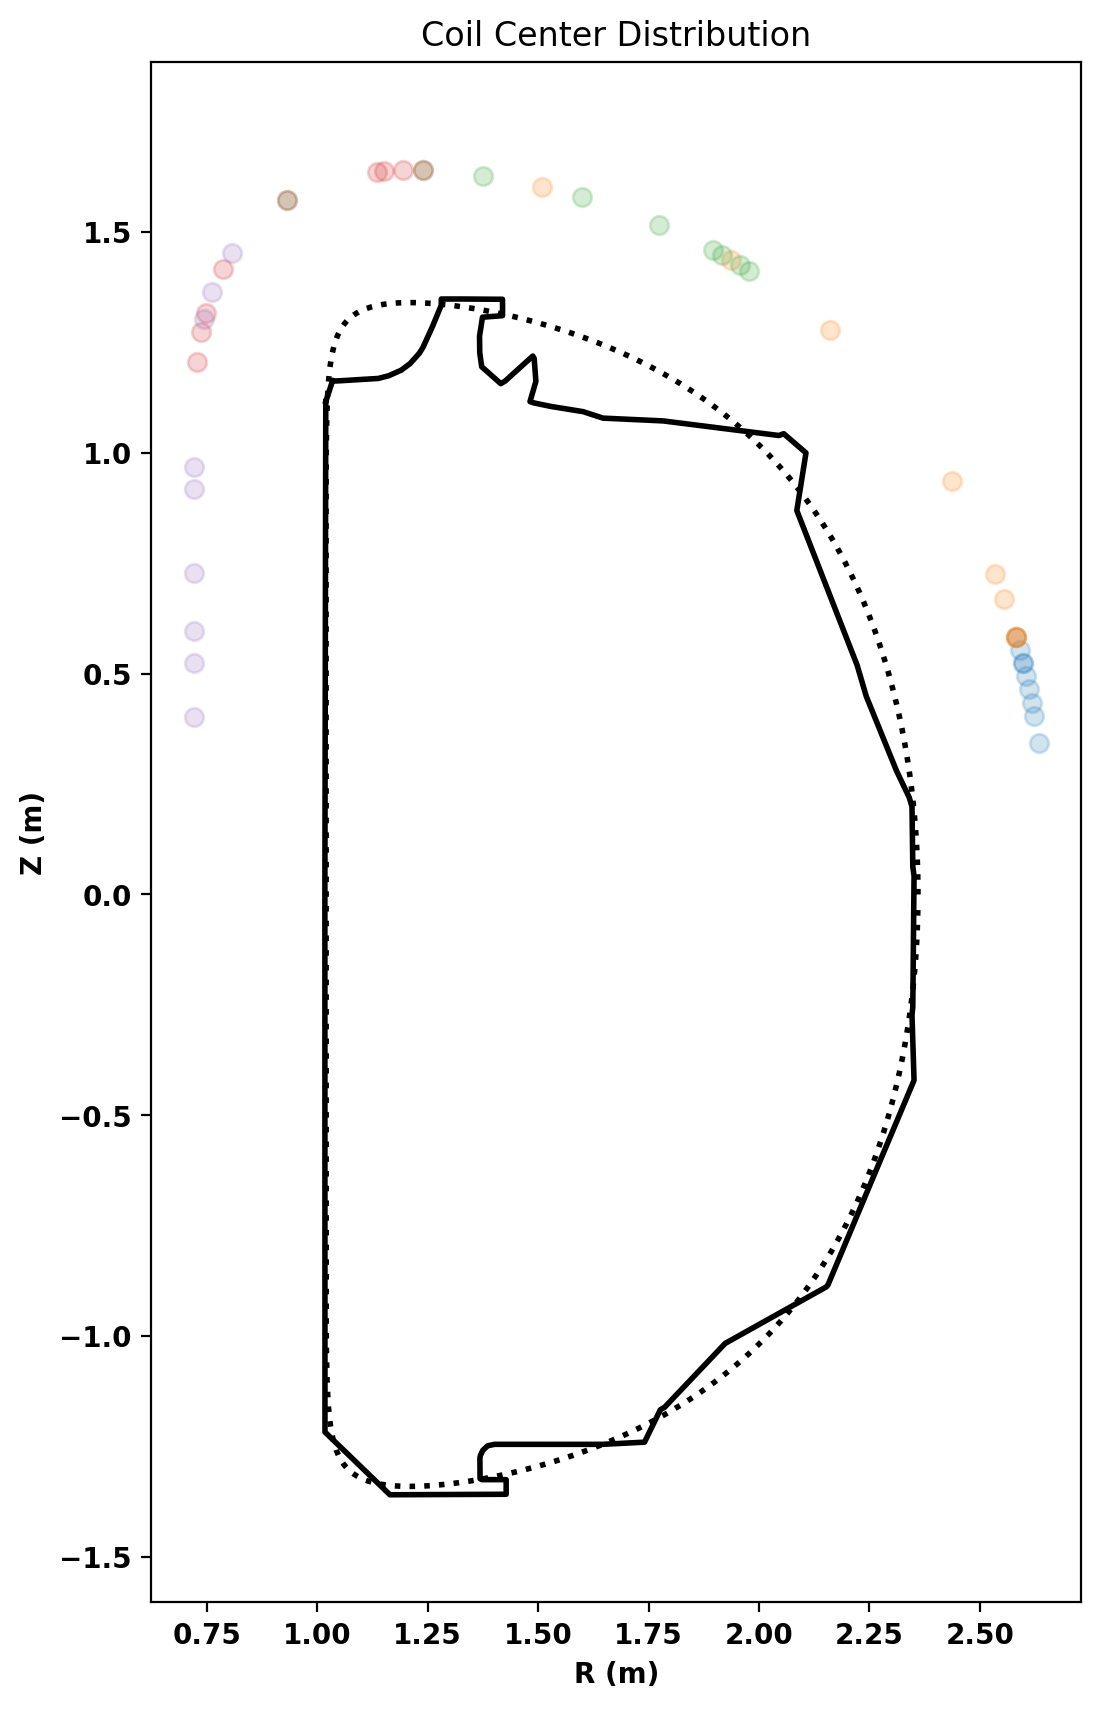

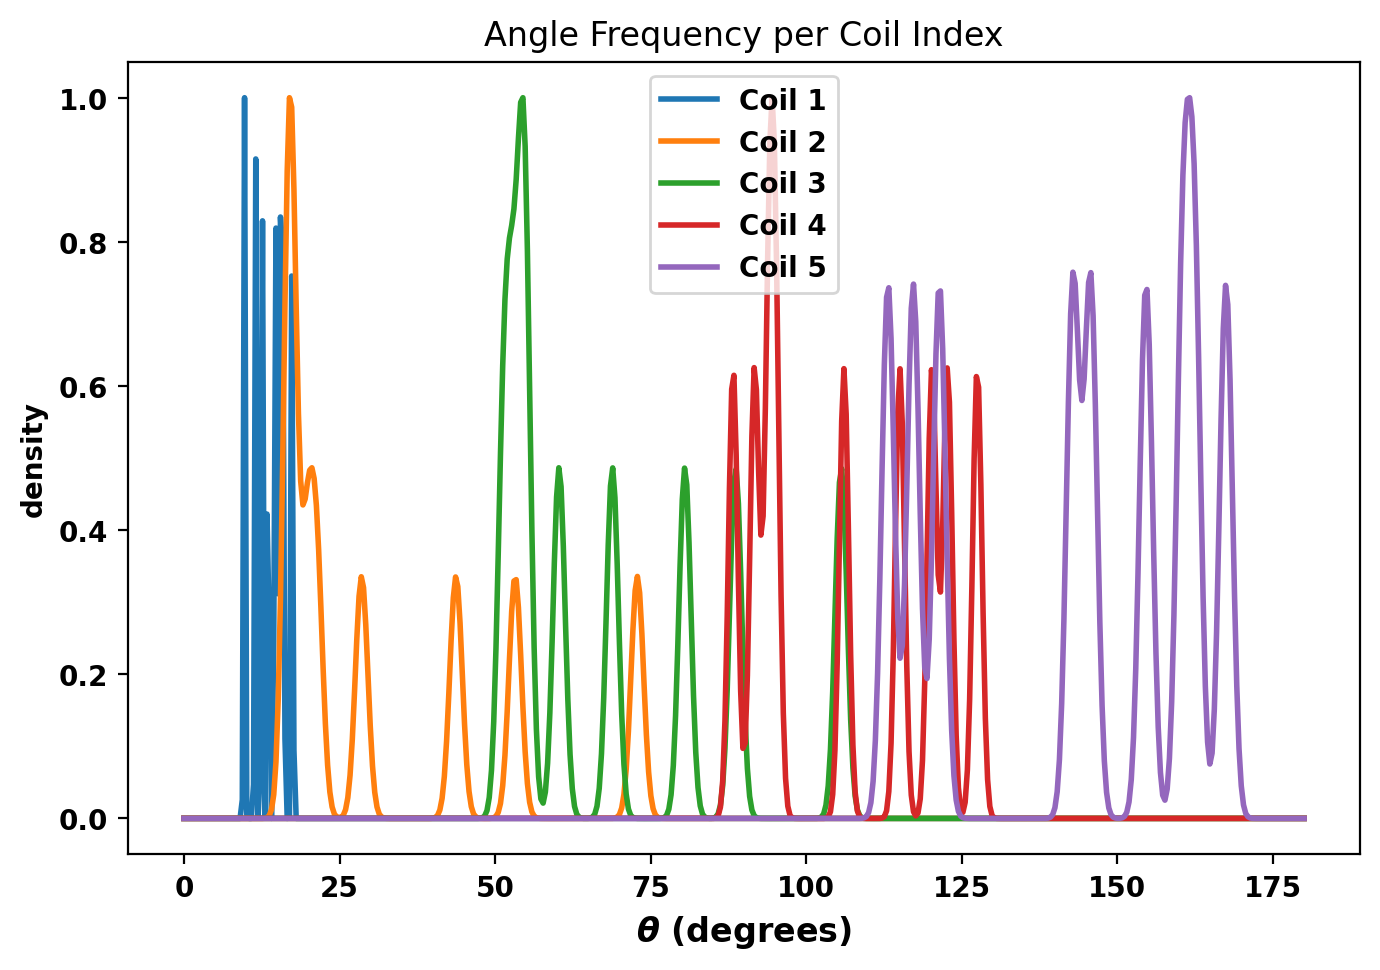

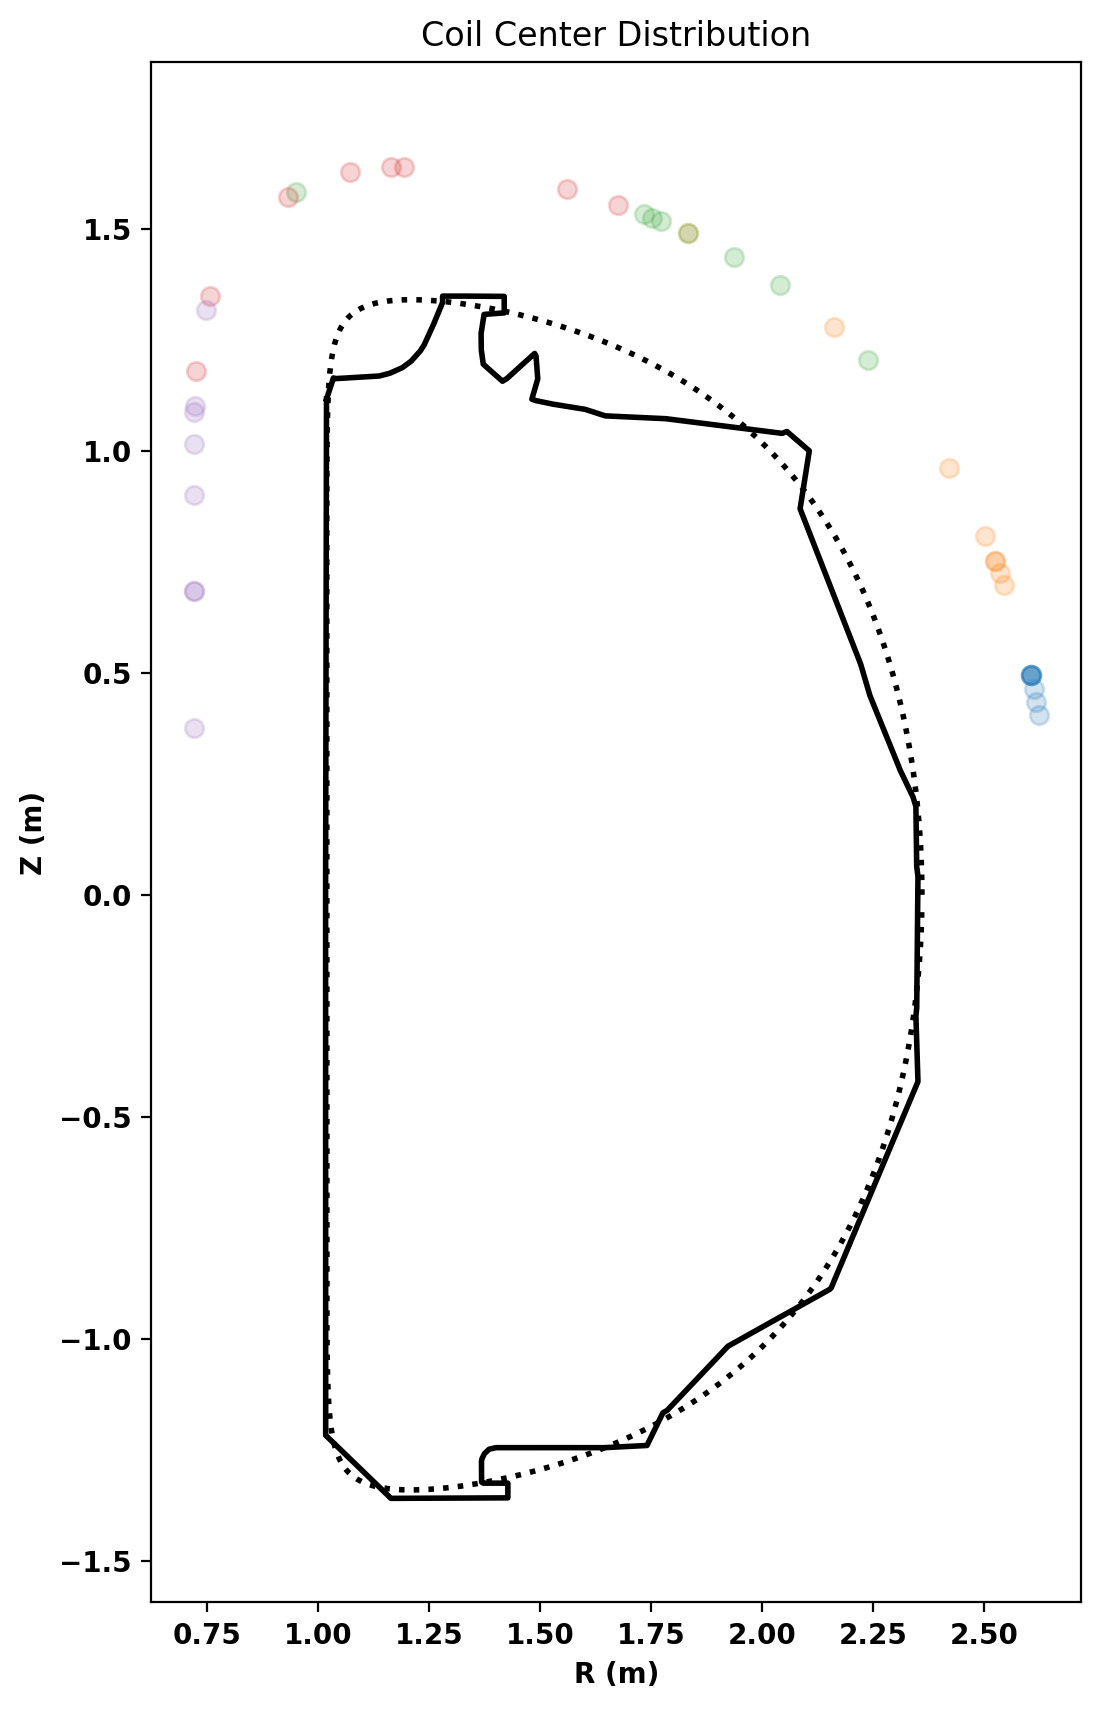

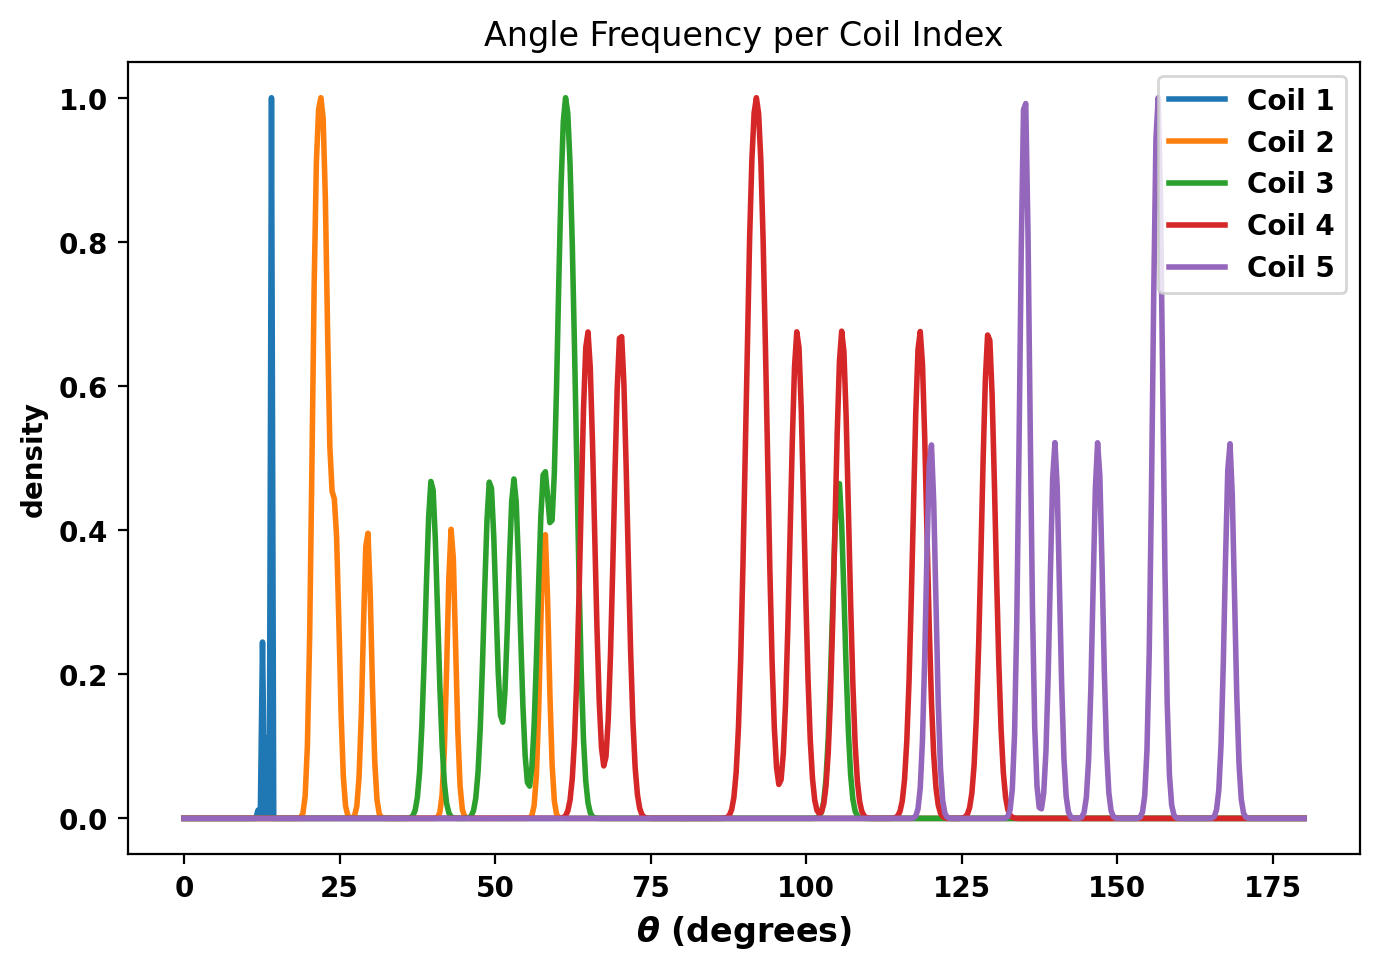

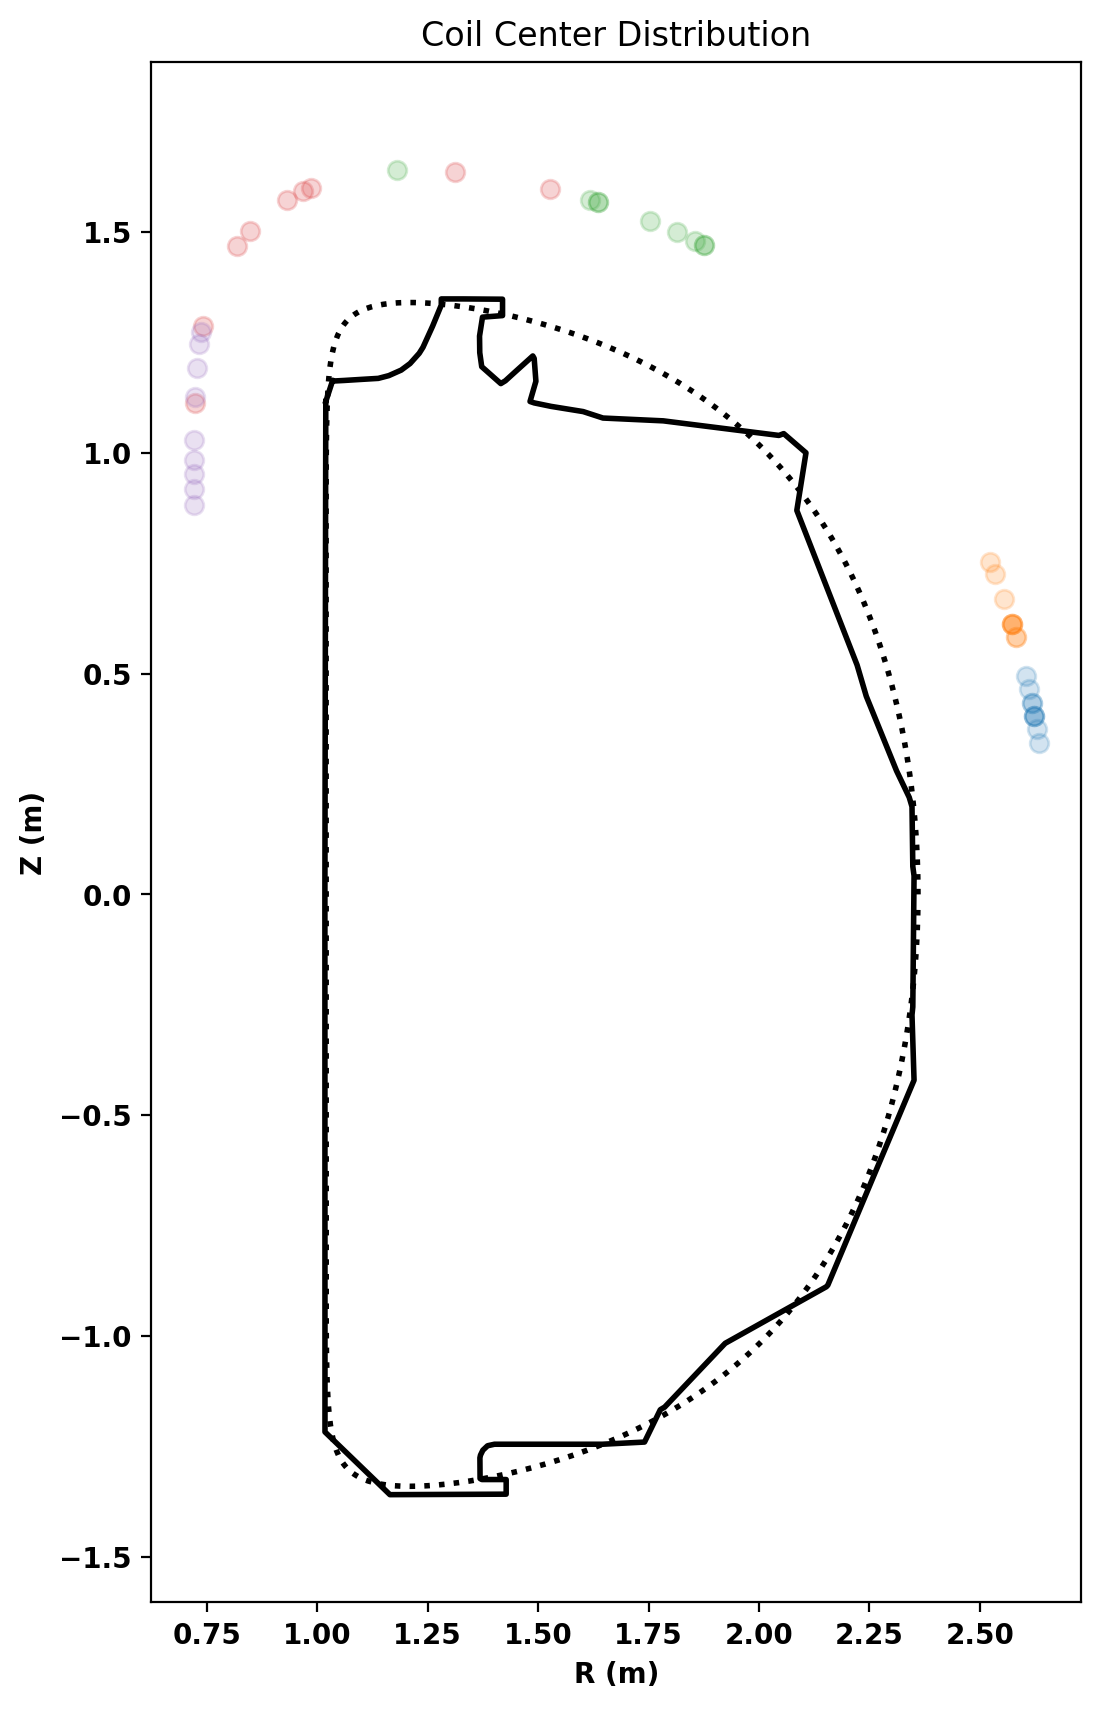

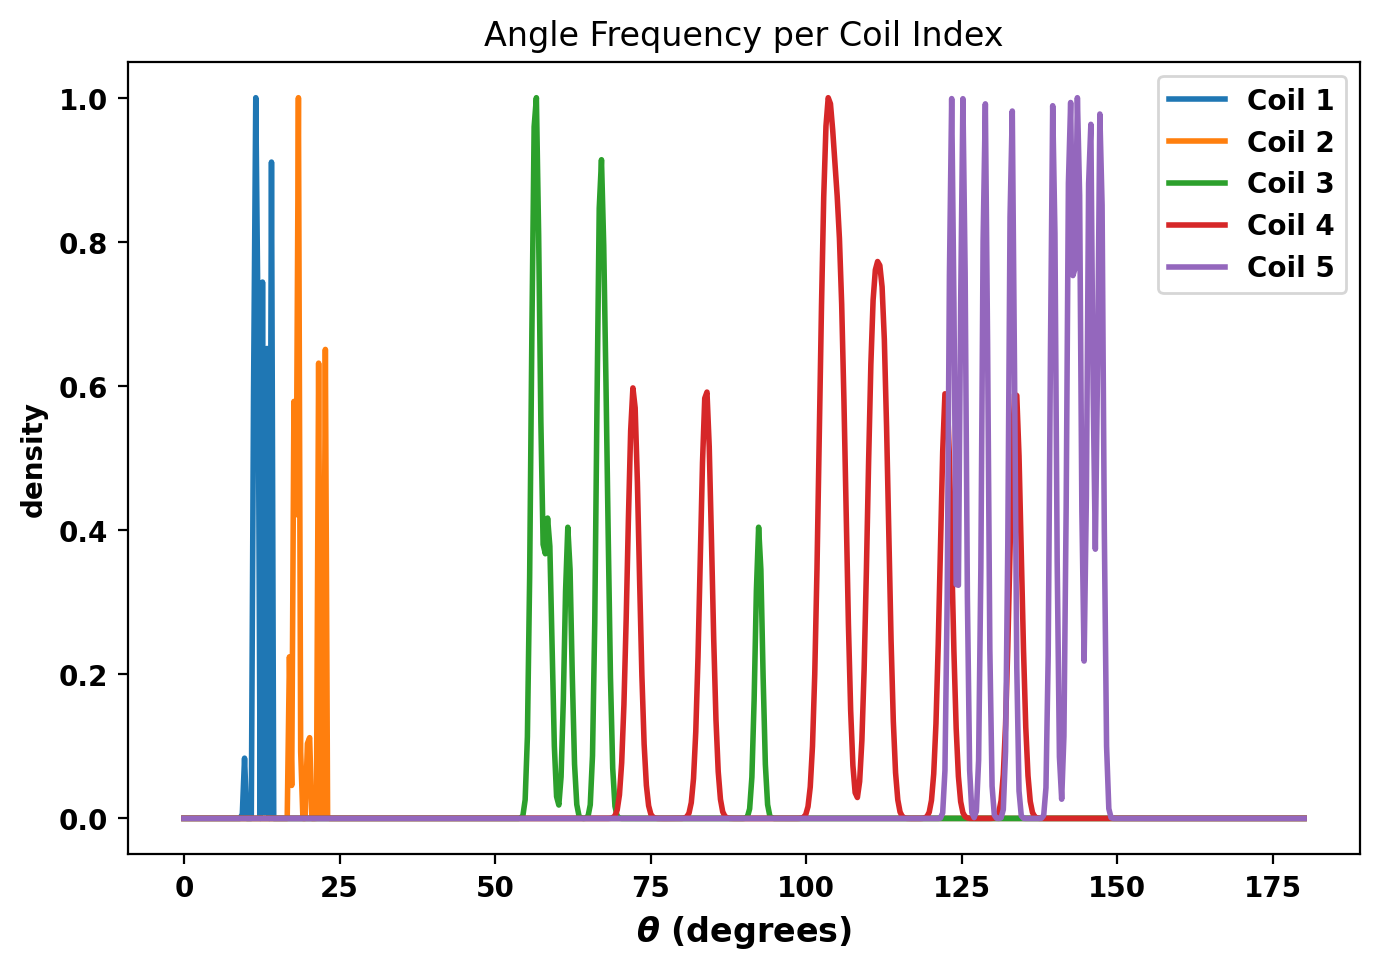

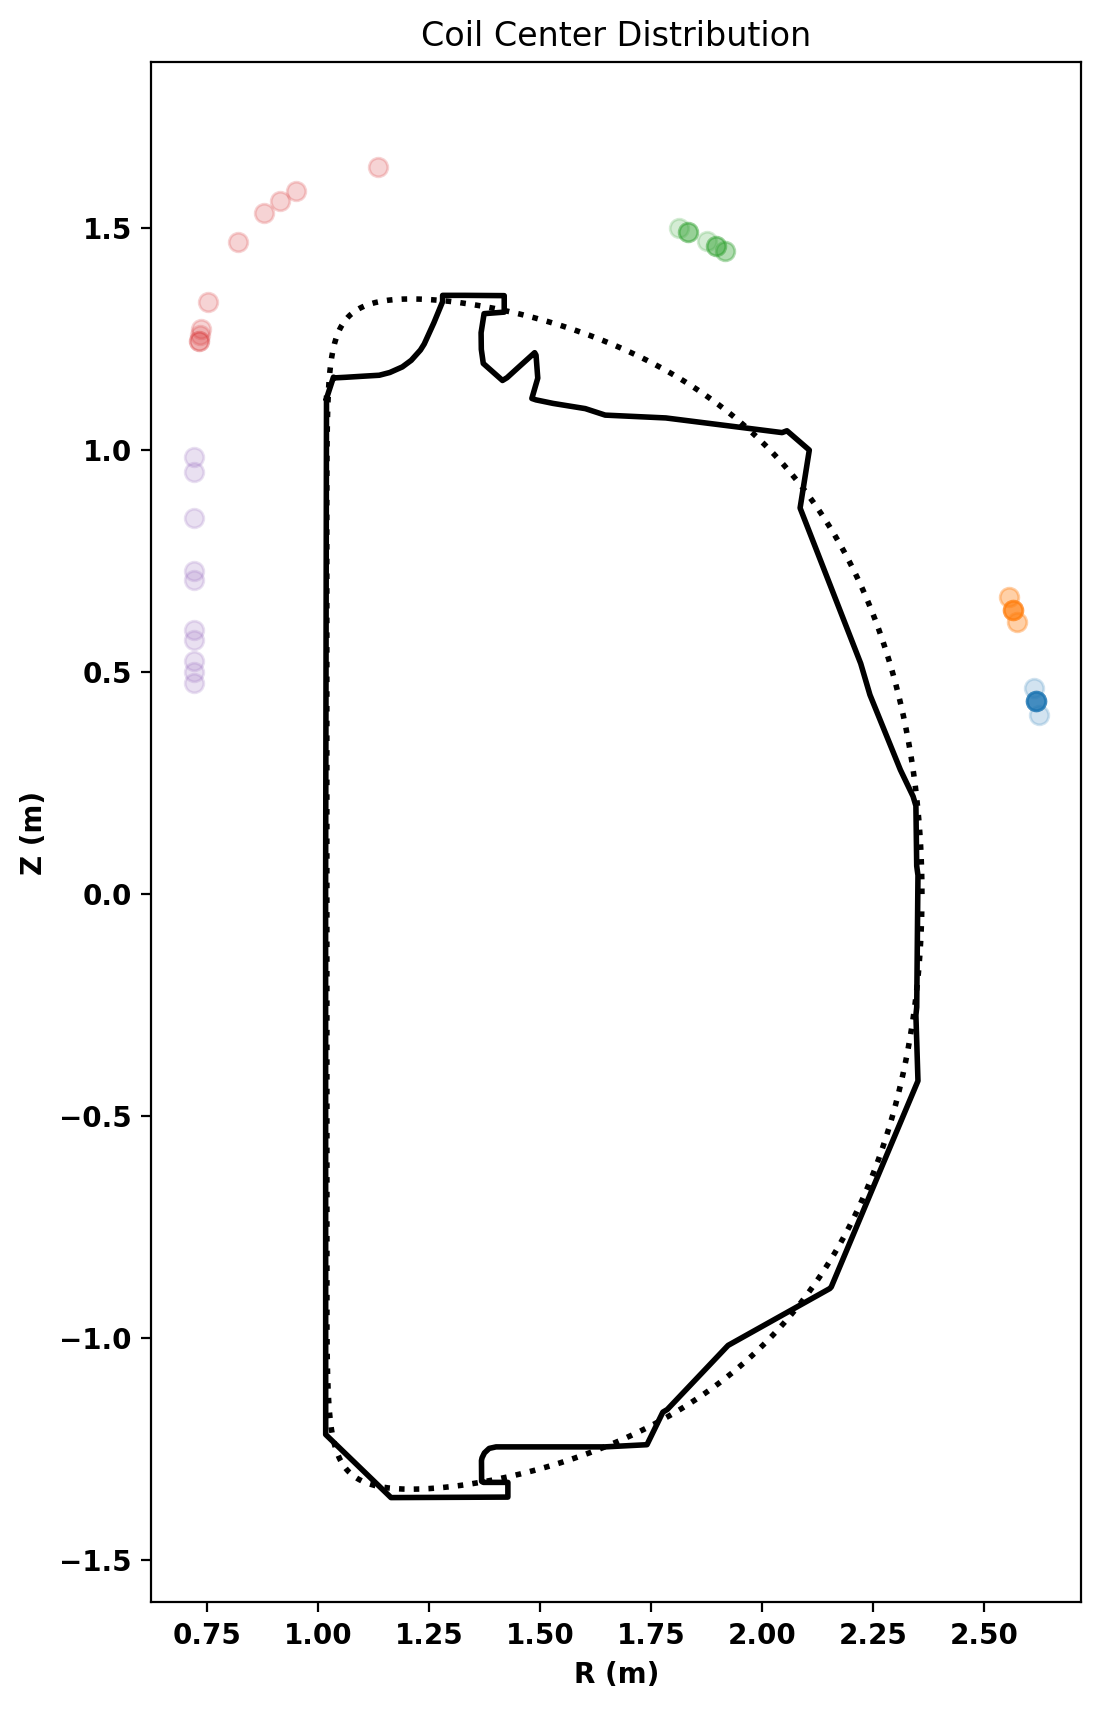

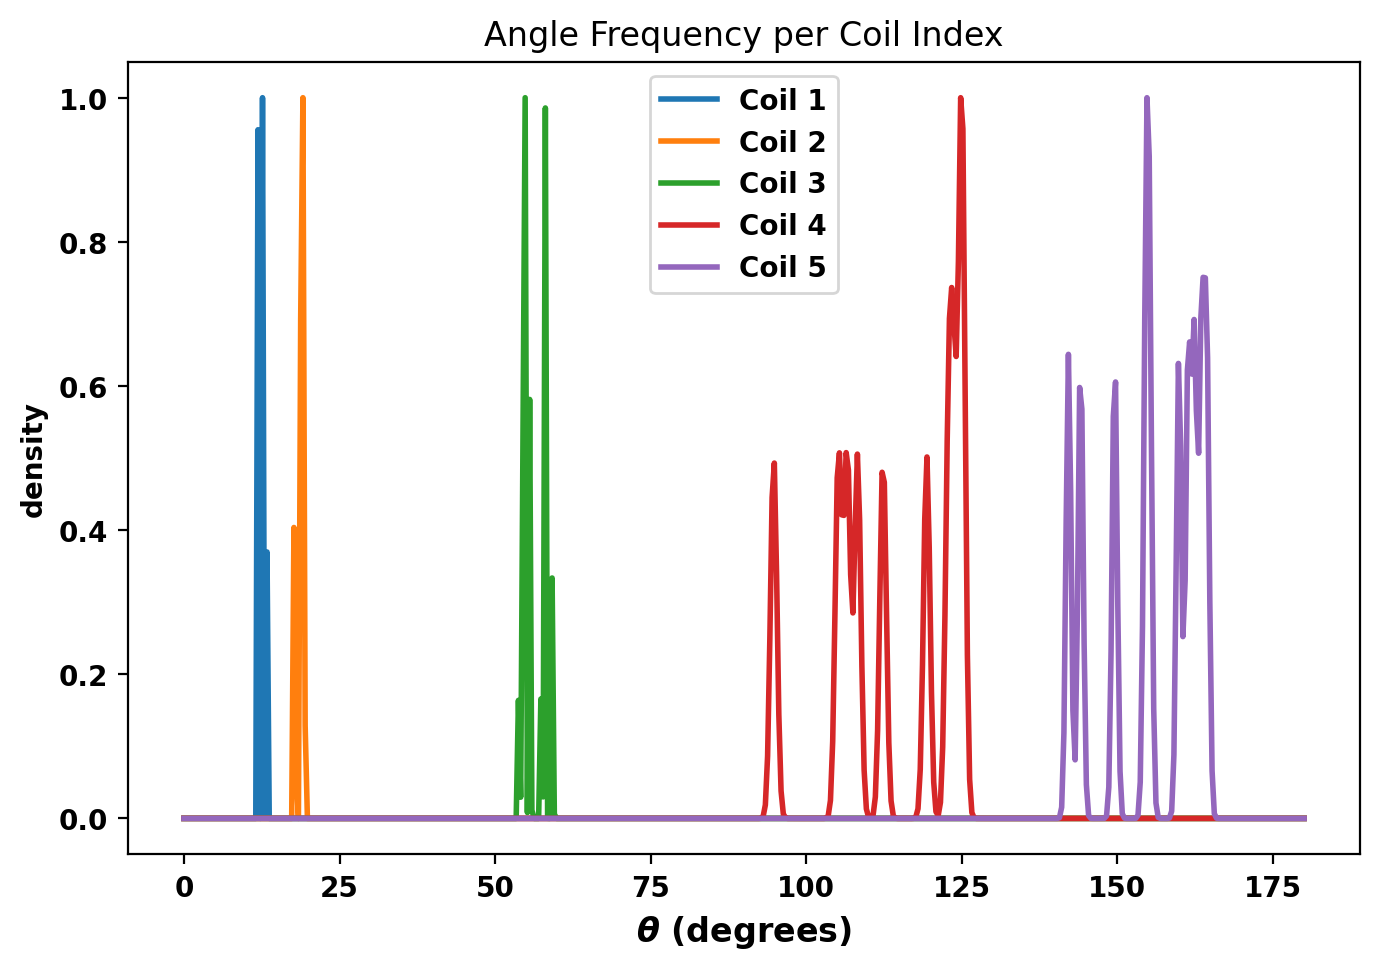

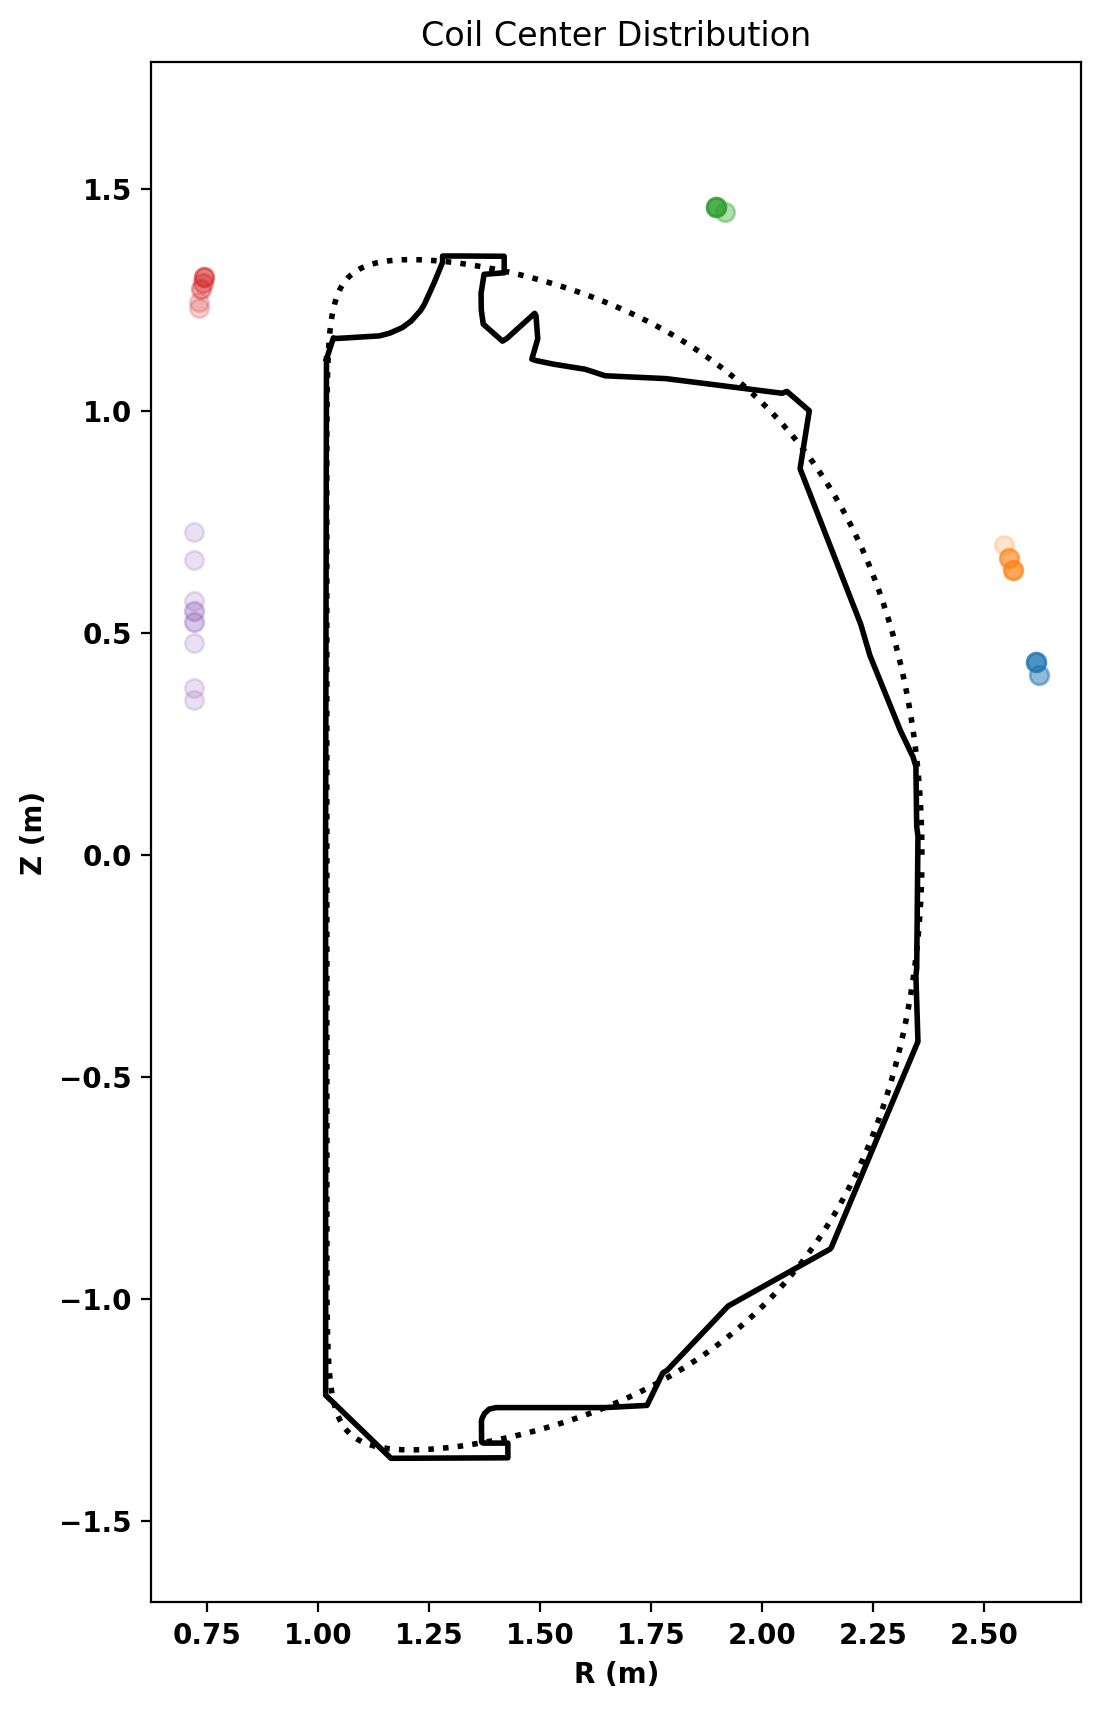

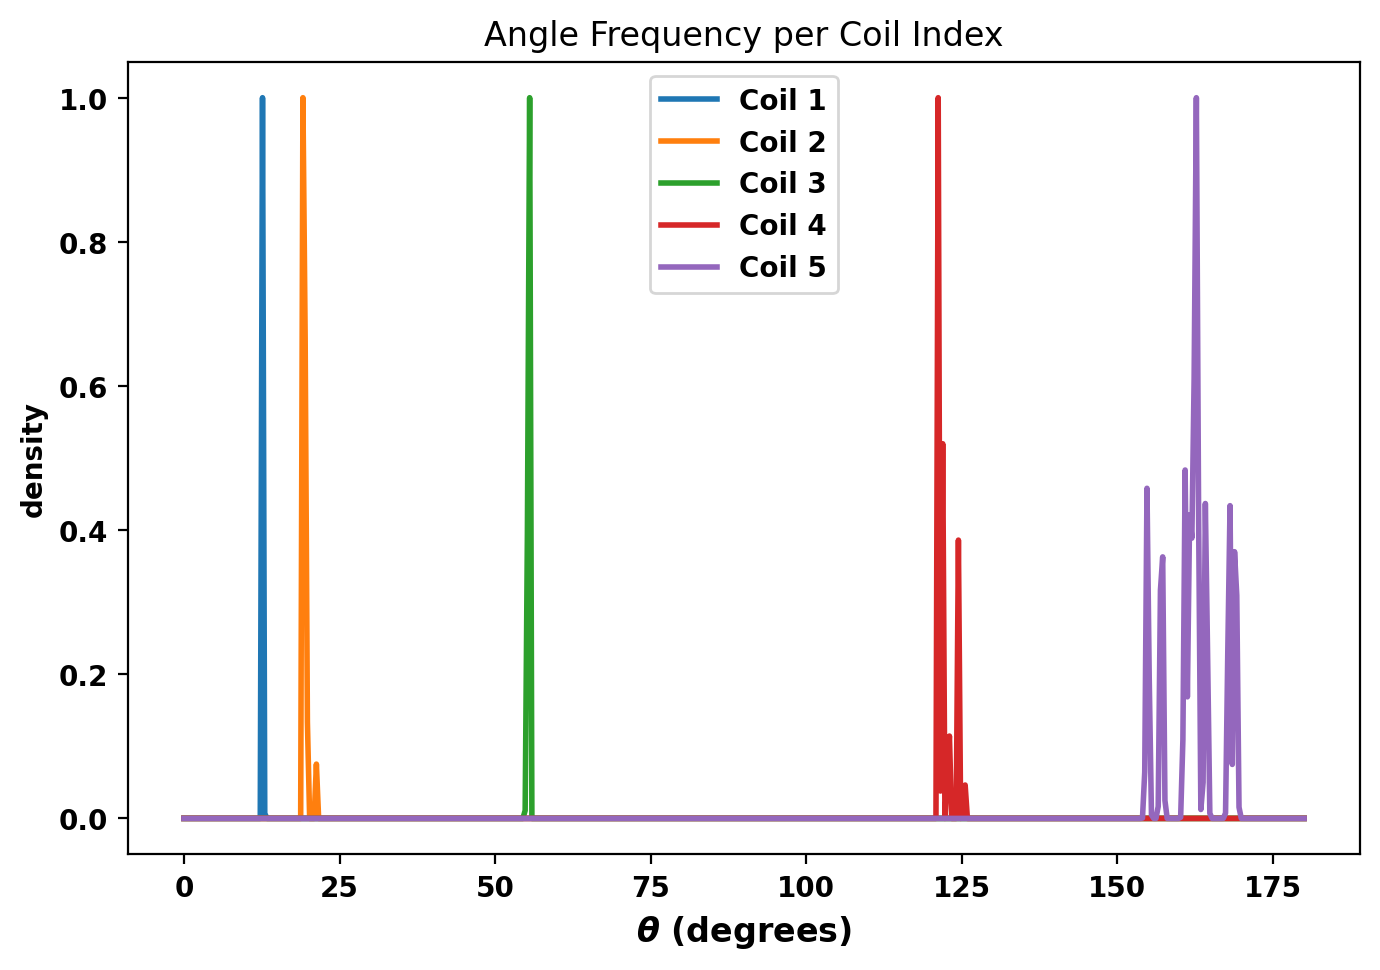

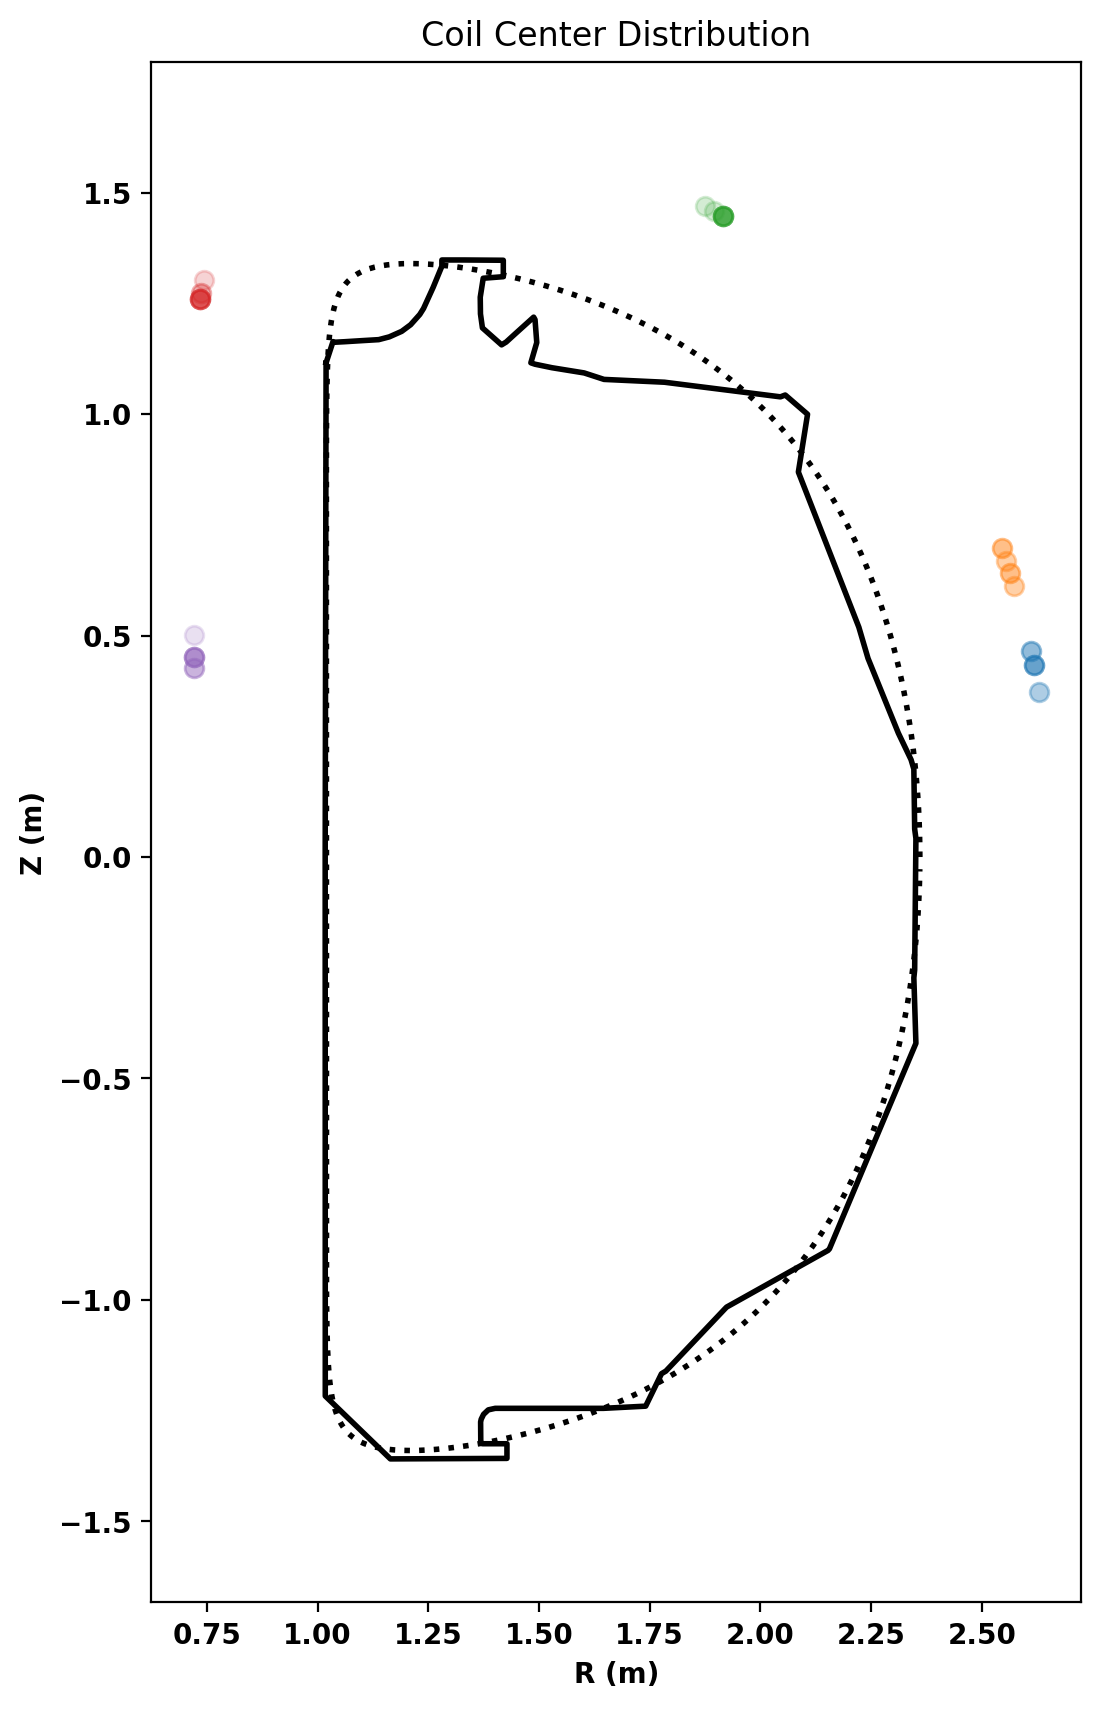

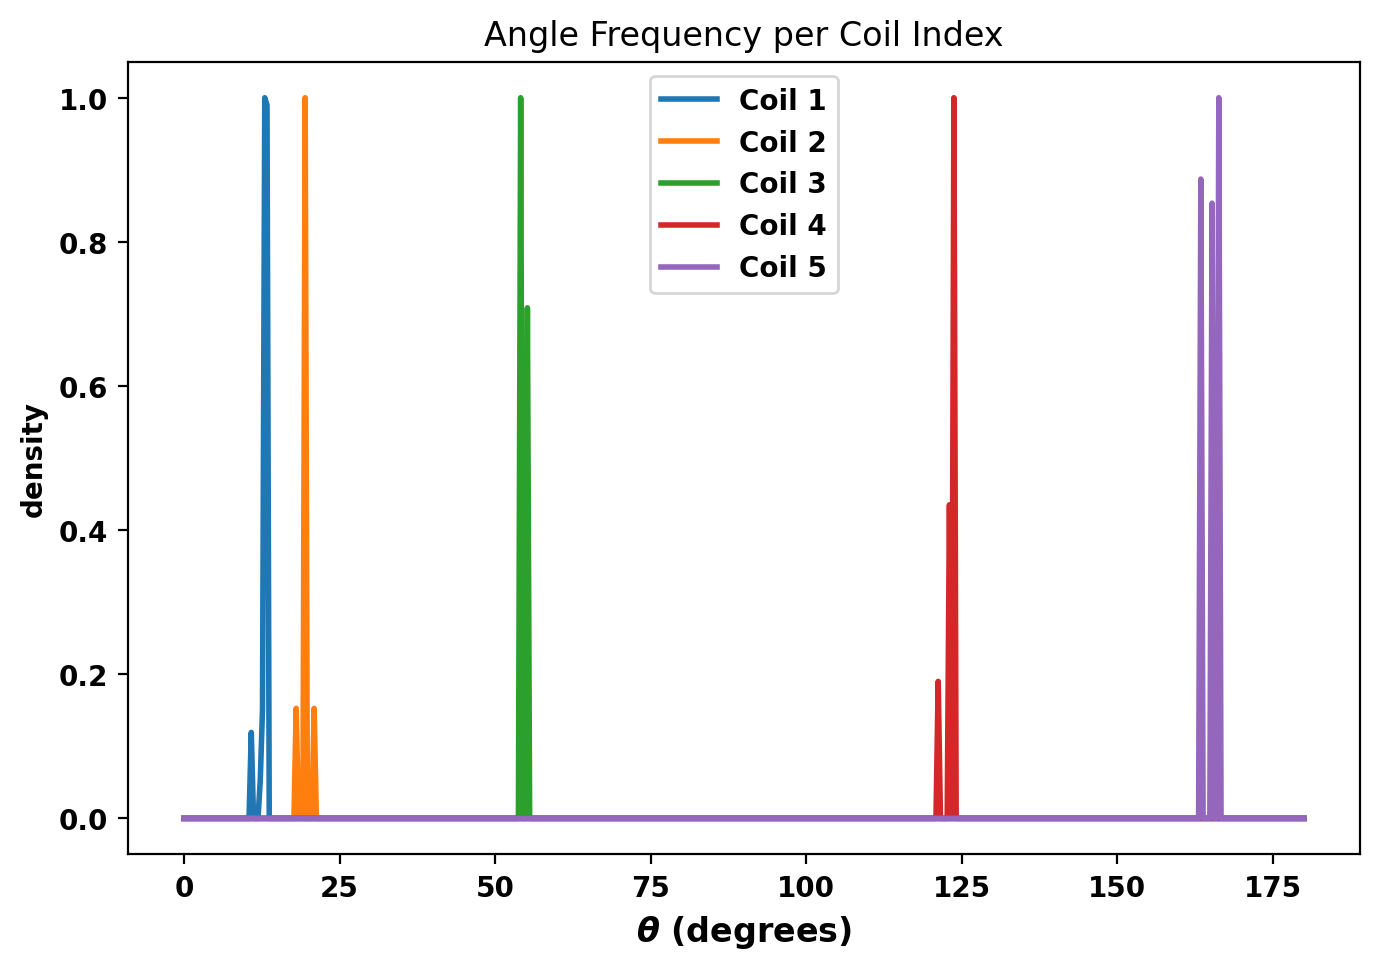

In [115]:
opt_pol_list, opt_curr_list = opt_coil_loc_full(ncoil, t, nb_distr, regin, regout, dtheta1, dtheta2, plot_steps=True)

### Currents analysis

In [125]:
tot_curr_list = []

# Loading the total current for each optimized distribution
for curr_distr in opt_curr_list:
    total_curr = np.sum(np.abs(curr_distr)) 
    tot_curr_list.append(total_curr)

In [126]:
def plot_total_currents(tot_curr_list):
    """
    Plots the total absolute current for each optimized current distribution.
    
    Parameters:
        opt_curr_list (list of lists): List where each element is a list of coil currents.
    """
    
    # Create x-axis: one value per distribution
    x = np.arange(len(tot_curr_list))

    # Getting the lowest currents distr
    min_index = np.argmin(tot_curr_list)
    lowest_currs = opt_curr_list[min_index]

    # Plotting
    plt.figure(figsize=(10, 5))
    plt.plot(x, tot_curr_list, marker='o', linestyle='-', linewidth=1, markersize=3)
    plt.xlabel("Distributions")
    plt.ylabel("$\sum_{i} |I_{i}|$", fontsize=12)
    plt.title("Total current per optimized distribution")
    plt.grid(True, linestyle='--', alpha=0.5)

    # Analysis of the lowest curr distr
    print("Lowest total current: ", np.sum(np.abs(lowest_currs)))
    print(f"Associated pol. angles distr: {opt_pol_list[min_index]} (distr N°{min_index})")
    print("Strongest current: ", max(np.abs(opt_curr_list[min_index])).item())

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_10298/3414320414.py:20: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sum_{i} |I_{i}|$", fontsize=12)


Lowest total current:  2723392.0978273423
Associated pol. angles distr: [ 12.54962477  19.30150665  54.16430866 123.18602279 163.3934978 ] (distr N°2)
Strongest current:  1024245.248221738


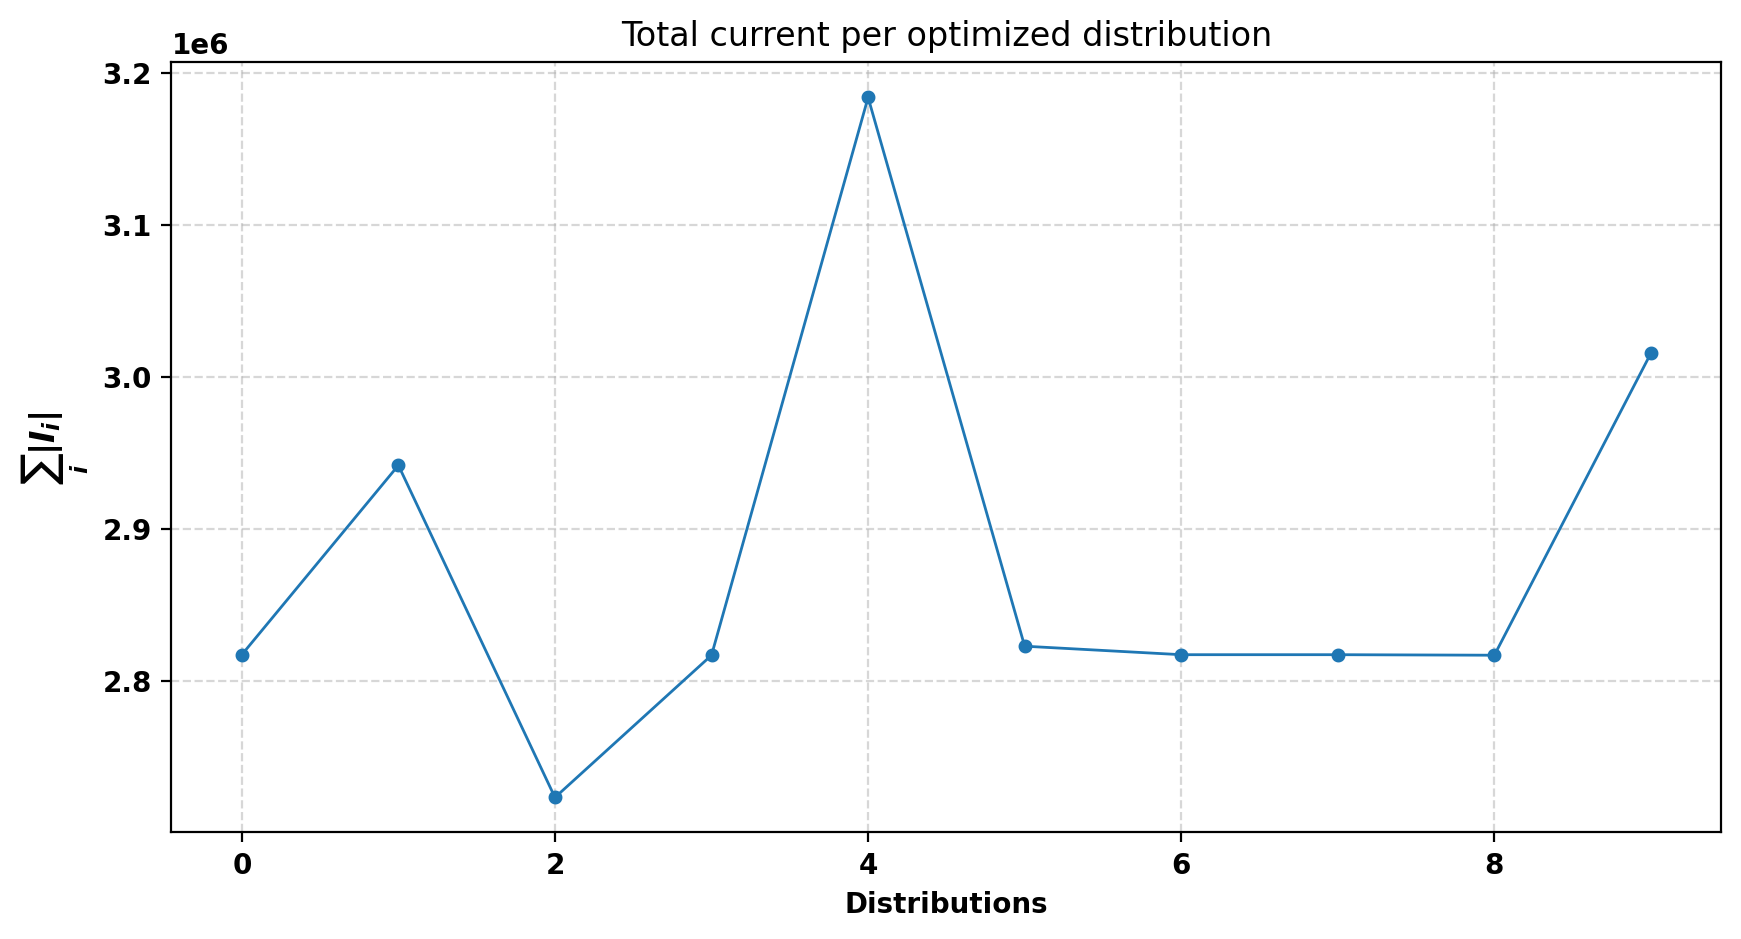

In [127]:
plot_total_currents(tot_curr_list)

### outliers analysis 